In [ ]:
# 1.Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
import polars as pl  # very fast and low memory
import glob , os , shap , time
import xgboost as xgb
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
tf.random.set_seed(42)
os.environ["LOKY_MAX_CPU_COUNT"] = "8"
import warnings
warnings.filterwarnings('ignore')

In [5]:
# 2.Load the ecommerce behaviour dataset

df = pd.read_csv('../data/cleaned_raw_data.csv')
print("First five rows of the dataset:")
df.head()

First five rows of the dataset:


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
1,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
2,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d
3,2019-10-01 00:00:05 UTC,view,1480613,2053013561092866779,computers.desktop,pulser,908.62,512742880,0d0d91c2-c9c2-4e81-90a5-86594dec0db9
4,2019-10-01 00:00:10 UTC,view,28719074,2053013565480109009,apparel.shoes.keds,baden,102.71,520571932,ac1cd4e5-a3ce-4224-a2d7-ff660a105880


In [6]:

# 3. Load whichever you need 
beh_df = pd.read_csv('../data/behavioural_features.csv')
trans_df = pd.read_csv('../data/transactional_features.csv')
hybrid_df = pd.read_csv('../data/hybrid_features.csv')

print(beh_df.columns.tolist())
print(trans_df.columns.tolist())

['user_id', 'sessions_per_user', 'active_duration', 'category_diversity', 'cart_count', 'purchase_count', 'view_count', 'cart_to_view_ratio', 'purchase_rate']
['user_id', 'total_purchase_amount', 'avg_order_value', 'num_purchases', 'total_views', 'total_carts', 'cart_abandonment_rate', 'conversion_rate', 'recency_days', 'first_purchase_gap_days', 'top_category', 'category_diversity']


In [ ]:
# 4. XGBoost CLV Modelling on Behavioural Features -- don't run

# ── 1. Feature Scaling ───────────────────────────────────────────────
def scale_behavioural_features(df, exclude_cols=['user_id']):
    """Scale numeric features using MinMaxScaler."""
    features = [col for col in df.columns 
                if col not in exclude_cols 
                and pd.api.types.is_numeric_dtype(df[col])]
    scaler = MinMaxScaler()
    df_scaled = df.copy()
    df_scaled[features] = scaler.fit_transform(df[features])
    print(f"Scaled {len(features)} features: {features}")
    return df_scaled, scaler

beh_df_scaled, scaler_beh = scale_behavioural_features(beh_df)

# ── 2. XGBoost Model Training ────────────────────────────────────────
def train_xgboost_on_behavioural(df_scaled, target_df):
    """Train XGBoost on behavioural features using CLV target from trans_df."""

    # Merge scaled behavioural features with target from trans_df
    df_model = df_scaled.merge(
        target_df[['user_id', 'total_purchase_amount']], 
        on='user_id', 
        how='inner'
    )

    # Features — drop user_id and target
    X = df_model.drop(columns=['user_id', 'total_purchase_amount'])
    X = X.select_dtypes(include=['number'])

    # Log-transform target to handle right skew
    y = np.log1p(df_model['total_purchase_amount'])

    print(f"Training samples  : {X.shape[0]:,} users")
    print(f"Number of features: {X.shape[1]}")
    print(f"Features used     : {list(X.columns)}")

    # 80/20 train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # ── Model Definition ─────────────────────────────────────────────
    model = XGBRegressor(
        objective        = 'reg:squarederror',
        n_estimators     = 150,
        max_depth        = 4,
        learning_rate    = 0.1,
        colsample_bytree = 0.7,
        reg_lambda       = 2,
        random_state     = 42,
        verbosity        = 0
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    # ── Evaluation ───────────────────────────────────────────────────
    y_pred = np.expm1(model.predict(X_test))
    y_true = np.expm1(y_test)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))  # Manual RMSE for compatibility
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    print("\nBehavioural XGBoost CLV Model Performance:")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")

    return model, X_train, X_test, y_true, y_pred

# Pass scaled behavioural features and trans_df as target source
model_beh, X_beh_train, X_beh_test, y_beh_true, y_beh_pred = train_xgboost_on_behavioural(beh_df_scaled, trans_df)

# ── 3. SHAP Feature Importance ───────────────────────────────────────
explainer   = shap.Explainer(model_beh, X_beh_train)
shap_values = explainer(X_beh_train)

print("\nSHAP Feature Importance (Top 10):")
shap.plots.bar(shap_values, max_display=10)
shap.plots.beeswarm(shap_values, max_display=10)

In [ ]:
# 5.Train Multiple Supervised Models on Behavioural Features -- don't run

def train_multiple_models_on_behavioural(df_scaled, target_df):
    """Train Decision Tree, Gradient Boosting and Random Forest on behavioural features."""

    # Merge scaled behavioural features with CLV target from trans_df
    df_model = df_scaled.merge(
        target_df[['user_id', 'total_purchase_amount']],
        on='user_id',
        how='inner'
    )

    # Features — drop identifier and target
    X = df_model.drop(columns=['user_id', 'total_purchase_amount'])
    X = X.select_dtypes(include=['number'])

    # Log-transform target to handle right skew
    y = np.log1p(df_model['total_purchase_amount'])

    print(f"Training samples  : {X.shape[0]:,} users")
    print(f"Number of features: {X.shape[1]}")
    print(f"Features used     : {list(X.columns)}")

    # 80/20 train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # ── Model Definitions ────────────────────────────────────────────
    models = {
        'Decision Tree'     : DecisionTreeRegressor(max_depth=10, random_state=42),
        'Gradient Boosting' : GradientBoostingRegressor(n_estimators=100, random_state=42),
        'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42)
    }

    results = {}

    for model_name, model in models.items():
        print(f"\nTraining {model_name}...")
        model.fit(X_train, y_train)

        # Inverse log-transform for interpretable metrics
        y_pred = np.expm1(model.predict(X_test))
        y_true = np.expm1(y_test)

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae  = mean_absolute_error(y_true, y_pred)
        r2   = r2_score(y_true, y_pred)

        results[model_name] = {
            'RMSE' : rmse,
            'MAE'  : mae,
            'R2'   : r2,
            'model': model
        }

        print(f"  RMSE : {rmse:.4f}")
        print(f"  MAE  : {mae:.4f}")
        print(f"  R²   : {r2:.4f}")

    return results, X_train, X_test

# Pass both scaled behavioural features and trans_df as target source
model_results, X_beh_train, X_beh_test = train_multiple_models_on_behavioural(beh_df_scaled, trans_df)

# ── Model Comparison Table ───────────────────────────────────────────
comparison_df = pd.DataFrame({
    model_name: {
        metric: value 
        for metric, value in metrics.items() 
        if metric != 'model'
    } 
    for model_name, metrics in model_results.items()
}).T

print("\n=== Behavioural Model Comparison ===")
print(comparison_df.to_string())

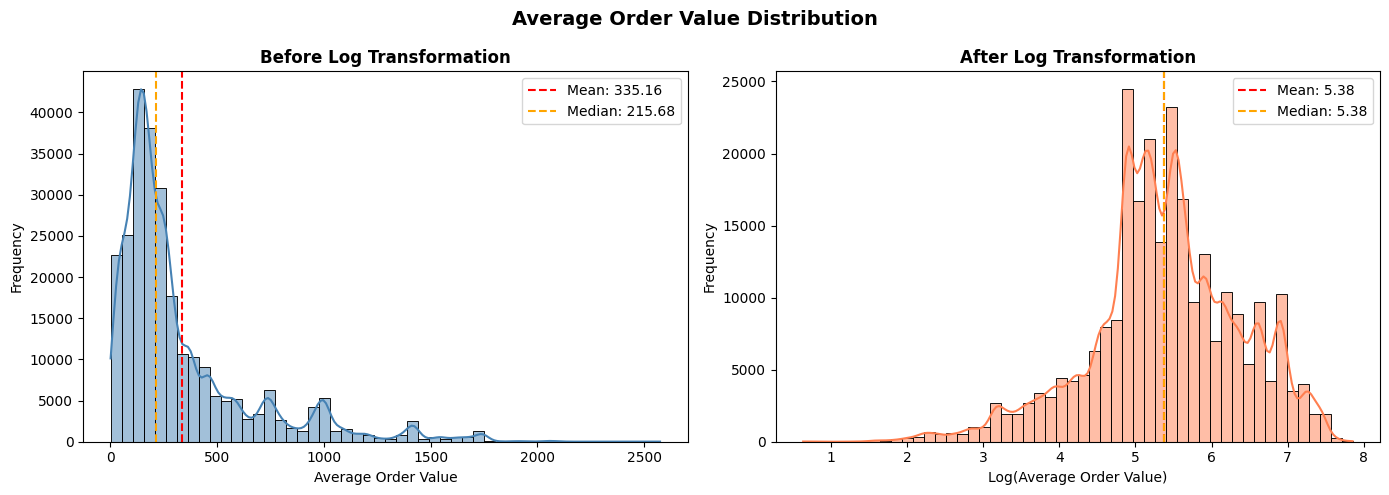

In [7]:
# 6. Visual inspection for Average Order Value — Before and After Log Transformation

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Average Order Value Distribution', fontsize=14, fontweight='bold')

# ── Before Log Transformation ────────────────────────────────────────
sns.histplot(hybrid_df['avg_order_value'], kde=True, color='steelblue', 
             bins=50, ax=axes[0])
axes[0].set_title('Before Log Transformation', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Average Order Value')
axes[0].set_ylabel('Frequency')
axes[0].axvline(hybrid_df['avg_order_value'].mean(), color='red', 
                linestyle='--', linewidth=1.5, label=f"Mean: {hybrid_df['avg_order_value'].mean():.2f}")
axes[0].axvline(hybrid_df['avg_order_value'].median(), color='orange', 
                linestyle='--', linewidth=1.5, label=f"Median: {hybrid_df['avg_order_value'].median():.2f}")
axes[0].legend()

# ── Apply Log Transformation ─────────────────────────────────────────
hybrid_df['avg_order_value_log'] = np.log1p(hybrid_df['avg_order_value'])

# ── After Log Transformation ─────────────────────────────────────────
sns.histplot(hybrid_df['avg_order_value_log'], kde=True, color='coral', 
             bins=50, ax=axes[1])
axes[1].set_title('After Log Transformation', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Log(Average Order Value)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(hybrid_df['avg_order_value_log'].mean(), color='red', 
                linestyle='--', linewidth=1.5, label=f"Mean: {hybrid_df['avg_order_value_log'].mean():.2f}")
axes[1].axvline(hybrid_df['avg_order_value_log'].median(), color='orange', 
                linestyle='--', linewidth=1.5, label=f"Median: {hybrid_df['avg_order_value_log'].median():.2f}")
axes[1].legend()

plt.tight_layout()
plt.show()

=== Before Outlier Removal ===
  Total users    : 263,380
  Mean CLV       : $773.97
  Median CLV     : $287.97
  Max CLV        : $265569.52
  99th Percentile: $7460.11


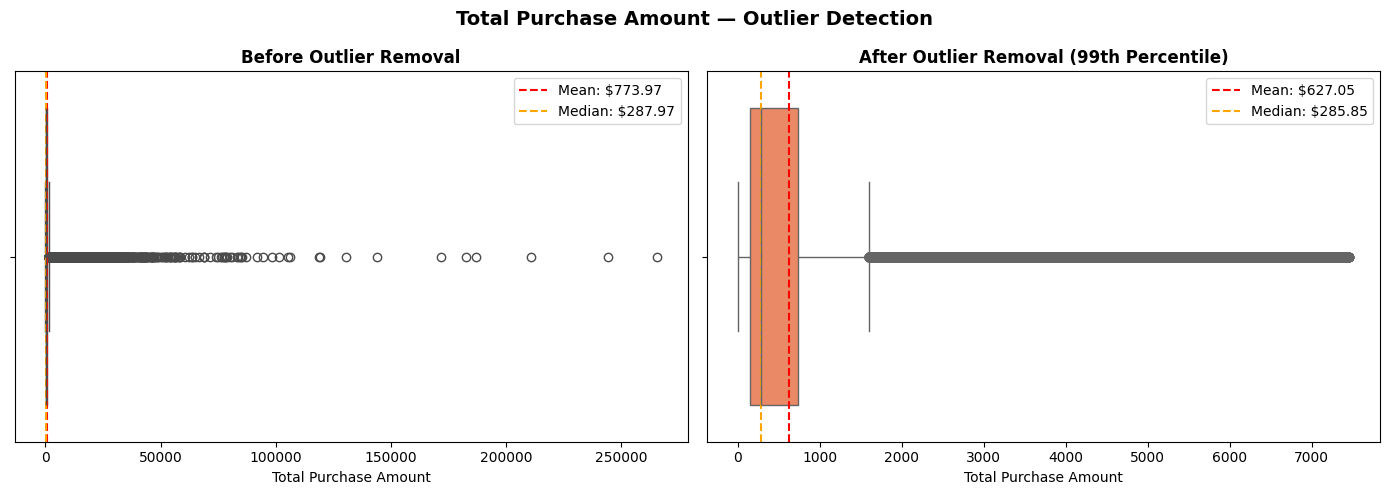


=== After Outlier Removal ===
  Total users    : 260,746
  Mean CLV       : $627.05
  Median CLV     : $285.85
  Max CLV        : $7459.80
  Threshold used : $7460.11
  Users removed  : 260,746 remaining after filtering


In [8]:
# 7. Outlier Detection for Total Purchase Amount (CLV Target)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Total Purchase Amount — Outlier Detection', fontsize=14, fontweight='bold')

# ── Before Filtering ─────────────────────────────────────────────────
sns.boxplot(x=hybrid_df['total_purchase_amount'], color='steelblue', ax=axes[0])
axes[0].set_title('Before Outlier Removal', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Purchase Amount')
axes[0].axvline(hybrid_df['total_purchase_amount'].mean(), color='red',
                linestyle='--', linewidth=1.5, label=f"Mean: ${hybrid_df['total_purchase_amount'].mean():.2f}")
axes[0].axvline(hybrid_df['total_purchase_amount'].median(), color='orange',
                linestyle='--', linewidth=1.5, label=f"Median: ${hybrid_df['total_purchase_amount'].median():.2f}")
axes[0].legend()

# Print summary stats before filtering
print("=== Before Outlier Removal ===")
print(f"  Total users    : {len(hybrid_df):,}")
print(f"  Mean CLV       : ${hybrid_df['total_purchase_amount'].mean():.2f}")
print(f"  Median CLV     : ${hybrid_df['total_purchase_amount'].median():.2f}")
print(f"  Max CLV        : ${hybrid_df['total_purchase_amount'].max():.2f}")
print(f"  99th Percentile: ${hybrid_df['total_purchase_amount'].quantile(0.99):.2f}")

# ── Apply 99th Percentile Threshold ──────────────────────────────────
threshold = hybrid_df['total_purchase_amount'].quantile(0.99)
hybrid_df = hybrid_df[hybrid_df['total_purchase_amount'] <= threshold]

# ── After Filtering ──────────────────────────────────────────────────
sns.boxplot(x=hybrid_df['total_purchase_amount'], color='coral', ax=axes[1])
axes[1].set_title('After Outlier Removal (99th Percentile)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Purchase Amount')
axes[1].axvline(hybrid_df['total_purchase_amount'].mean(), color='red',
                linestyle='--', linewidth=1.5, label=f"Mean: ${hybrid_df['total_purchase_amount'].mean():.2f}")
axes[1].axvline(hybrid_df['total_purchase_amount'].median(), color='orange',
                linestyle='--', linewidth=1.5, label=f"Median: ${hybrid_df['total_purchase_amount'].median():.2f}")
axes[1].legend()

plt.tight_layout()
plt.show()

# Print summary stats after filtering
print("\n=== After Outlier Removal ===")
print(f"  Total users    : {len(hybrid_df):,}")
print(f"  Mean CLV       : ${hybrid_df['total_purchase_amount'].mean():.2f}")
print(f"  Median CLV     : ${hybrid_df['total_purchase_amount'].median():.2f}")
print(f"  Max CLV        : ${hybrid_df['total_purchase_amount'].max():.2f}")
print(f"  Threshold used : ${threshold:.2f}")
print(f"  Users removed  : {len(hybrid_df):,} remaining after filtering")

All 6 clustering features found.


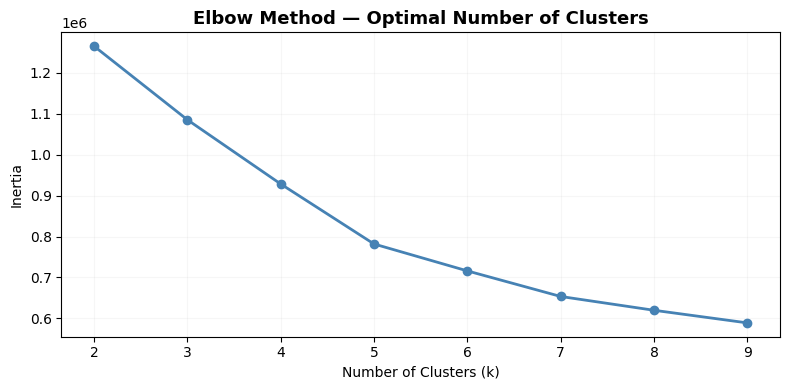


Clustering complete.
Segment distribution:
customer_segment
0     36565
1     11700
2     22239
3    190242
Name: count, dtype: int64

=== Cluster Profile Summary ===
                  num_purchases  avg_order_value  total_views  total_carts  recency_days  category_diversity  total_purchase_amount
customer_segment                                                                                                                   
0                          1.69          1011.06        15.81         1.68         13.65                1.73                1661.82
1                          8.49           311.86        54.10        11.99          8.29                3.25                2476.68
2                          2.09           217.15       107.60         2.51         12.83                7.74                 481.43
3                          1.50           212.79        16.46         1.55         14.22                1.89                 331.44


In [ ]:
# 8. Customer Segmentation via KMeans Clustering

# ── 1. Feature Selection for Clustering ─────────────────────────────
cluster_features = [
    'num_purchases', 
    'avg_order_value', 
    'total_views',
    'total_carts', 
    'recency_days', 
    'category_diversity'
]

# Verify all features exist before clustering
missing = [f for f in cluster_features if f not in hybrid_df.columns]
if missing:
    print(f"Warning: Missing features: {missing}")
else:
    print(f"All {len(cluster_features)} clustering features found.")

# ── 2. Feature Scaling ───────────────────────────────────────────────
# StandardScaler used for clustering — ensures no single feature dominates
scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(hybrid_df[cluster_features])

# ── 3. Optimal K Selection via Elbow Method ──────────────────────────
inertia = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method — Optimal Number of Clusters', fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True, alpha=0.1)
plt.tight_layout()
plt.show()

# ── 4. KMeans Fitting with k=4 ───────────────────────────────────────
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
hybrid_df['customer_segment'] = kmeans.fit_predict(X_cluster)

print(f"\nClustering complete.")
print(f"Segment distribution:\n{hybrid_df['customer_segment'].value_counts().sort_index()}")

# ── 5. Cluster Profile Summary ───────────────────────────────────────
cluster_summary = hybrid_df.groupby('customer_segment')[cluster_features + ['total_purchase_amount']].mean().round(2)
print("\n=== Cluster Profile Summary ===")
print(cluster_summary.to_string())

In [ ]:
# 9. Hybrid Modelling — XGBoost per Customer Segment

# ── 1. Feature Preparation ───────────────────────────────────────────
def clean_features(df, target='total_purchase_amount'):
    """Drop identifier and non-numeric columns, return X and y."""
    X = df.drop(columns=['user_id', target, 'top_category', 
                         'customer_segment'], errors='ignore')
    y = np.log1p(df[target])  # Log-transform target to handle right skew
    return X.select_dtypes(include=['number']), y

# ── 2. Segment-wise XGBoost Training ────────────────────────────────
def train_hybrid_model_by_segment(df, target='total_purchase_amount'):
    """Train an XGBoost model independently per customer segment."""
    
    metrics  = {}
    models   = {}
    segments = sorted(df['customer_segment'].unique())

    print("=" * 50)
    print("Hybrid XGBoost — Segment-wise CLV Modelling")
    print("=" * 50)

    for seg in segments:
        df_seg = df[df['customer_segment'] == seg].copy()

        # Skip segments with insufficient data for reliable modelling
        if len(df_seg) < 50:
            print(f"\nSegment {seg} skipped — insufficient samples ({len(df_seg)})")
            continue

        X, y = clean_features(df_seg, target)

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        # ── Model Definition ─────────────────────────────────────────
        model = XGBRegressor(
            objective        = 'reg:squarederror',
            n_estimators     = 150,
            max_depth        = 4,
            learning_rate    = 0.1,
            colsample_bytree = 0.7,
            reg_lambda       = 2,
            random_state     = 42,
            verbosity        = 0
        )

        model.fit(X_train, y_train, 
                  eval_set=[(X_test, y_test)], 
                  verbose=False)

        # Inverse log-transform for interpretable metrics
        y_pred = np.expm1(model.predict(X_test))
        y_true = np.expm1(y_test)

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae  = mean_absolute_error(y_true, y_pred)
        r2   = r2_score(y_true, y_pred)

        metrics[seg] = {
            'Segment Size' : len(df_seg),
            'RMSE'         : round(rmse, 4),
            'MAE'          : round(mae, 4),
            'R2'           : round(r2, 4)
        }
        models[seg] = model

        print(f"\nSegment {seg} ({len(df_seg):,} users)")
        print(f"  RMSE : {rmse:.4f}")
        print(f"  MAE  : {mae:.4f}")
        print(f"  R²   : {r2:.4f}")

    # ── Segment Comparison Table ─────────────────────────────────────
    print("\n" + "=" * 50)
    print("Segment Performance Summary")
    print("=" * 50)
    summary_df = pd.DataFrame(metrics).T
    print(summary_df.to_string())

    return metrics, models

# ── 3. Run Hybrid Model ──────────────────────────────────────────────
segment_metrics, segment_models = train_hybrid_model_by_segment(hybrid_df)

Hybrid XGBoost — Segment-wise CLV Modelling

Segment 0 (36,565 users)
  RMSE : 32.9635
  MAE  : 15.1941
  R²   : 0.9992

Segment 1 (11,700 users)
  RMSE : 102.0880
  MAE  : 57.6322
  R²   : 0.9969

Segment 2 (22,239 users)
  RMSE : 32.9049
  MAE  : 11.6589
  R²   : 0.9977

Segment 3 (190,242 users)
  RMSE : 8.7239
  MAE  : 4.1485
  R²   : 0.9994

Segment Performance Summary
   Segment Size      RMSE      MAE      R2
0       36565.0   32.9635  15.1941  0.9992
1       11700.0  102.0880  57.6322  0.9969
2       22239.0   32.9049  11.6589  0.9977
3      190242.0    8.7239   4.1485  0.9994


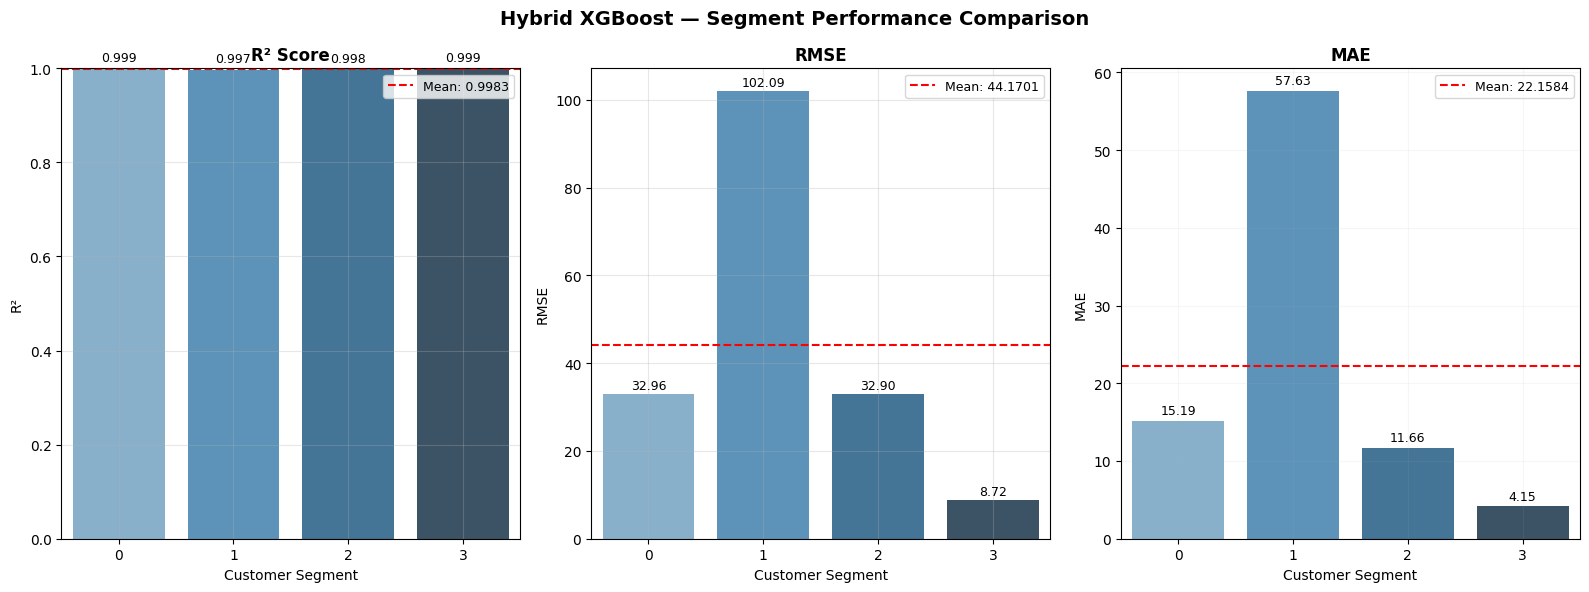


=== Segment Performance Summary ===
Segment     R2     RMSE     MAE
      0 0.9992  32.9635 15.1941
      1 0.9969 102.0880 57.6322
      2 0.9977  32.9049 11.6589
      3 0.9994   8.7239  4.1485


In [13]:
# 10. Hybrid Model — Performance Visualisation by Segment

def plot_hybrid_performance(metrics):
    """Plot R², RMSE and MAE performance across customer segments."""

    # Build results dataframe
    df_results = pd.DataFrame(metrics).T.reset_index()
    df_results.rename(columns={'index': 'Segment'}, inplace=True)
    df_results['Segment'] = df_results['Segment'].astype(str)

    fig, axes = plt.subplots(1, 3, figsize=(16, 6))
    fig.suptitle('Hybrid XGBoost — Segment Performance Comparison', 
                 fontsize=14, fontweight='bold')

    palette = sns.color_palette('Blues_d', len(df_results))

    # ── R² Score ────────────────────────────────────────────────────
    sns.barplot(x='Segment', y='R2', data=df_results, 
                palette=palette, ax=axes[0])
    axes[0].set_title('R² Score', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Customer Segment')
    axes[0].set_ylabel('R²')
    axes[0].set_ylim(0, 1)
    axes[0].axhline(df_results['R2'].mean(), color='red', linestyle='--', 
                    linewidth=1.5, label=f"Mean: {df_results['R2'].mean():.4f}")
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)
    for bar in axes[0].patches:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=9)

    # ── RMSE ─────────────────────────────────────────────────────────
    sns.barplot(x='Segment', y='RMSE', data=df_results, 
                palette=palette, ax=axes[1])
    axes[1].set_title('RMSE', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Customer Segment')
    axes[1].set_ylabel('RMSE')
    axes[1].axhline(df_results['RMSE'].mean(), color='red', linestyle='--',
                    linewidth=1.5, label=f"Mean: {df_results['RMSE'].mean():.4f}")
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)
    for bar in axes[1].patches:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f"{bar.get_height():.2f}", ha='center', va='bottom', fontsize=9)

    # ── MAE ──────────────────────────────────────────────────────────
    sns.barplot(x='Segment', y='MAE', data=df_results, 
                palette=palette, ax=axes[2])
    axes[2].set_title('MAE', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Customer Segment')
    axes[2].set_ylabel('MAE')
    axes[2].axhline(df_results['MAE'].mean(), color='red', linestyle='--',
                    linewidth=1.5, label=f"Mean: {df_results['MAE'].mean():.4f}")
    axes[2].legend(fontsize=9)
    axes[2].grid(True, alpha=0.1)
    for bar in axes[2].patches:
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f"{bar.get_height():.2f}", ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

    # ── Summary Table ────────────────────────────────────────────────
    print("\n=== Segment Performance Summary ===")
    print(df_results[['Segment', 'R2', 'RMSE', 'MAE']].to_string(index=False))

    return df_results

# Run hybrid model and plot results
df_hybrid_results = plot_hybrid_performance(segment_metrics)


Benchmark Summary
                       RMSE       MAE      R2
Model                                        
Segmented XGBoost   44.1701   22.1584  0.9983
Mean Baseline      917.3879  570.0012 -0.0001
Linear Regression  437.1086  216.7460  0.7730


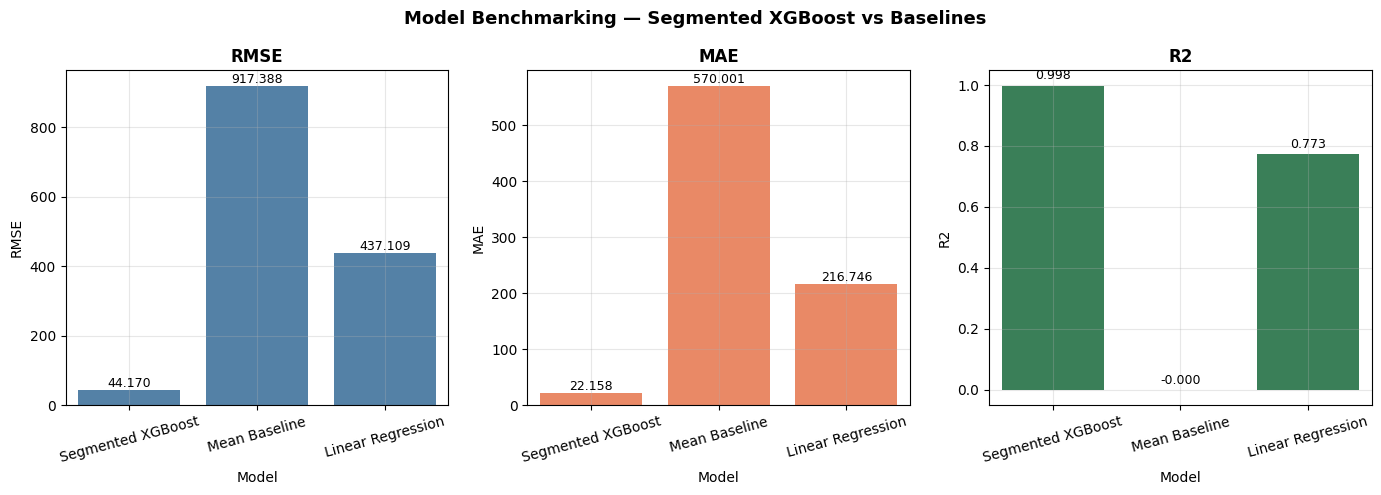

In [ ]:
# 11. Run and Benchmark — Segmented XGBoost vs Baseline Models

# ── 1. Run Segmented Hybrid Model ────────────────────────────────────
# segment_metrics, segment_models = train_hybrid_model_by_segment(hybrid_df)

# ── 2. Average Metrics Across Segments ──────────────────────────────
seg_rmse = np.mean([v['RMSE'] for v in segment_metrics.values()])
seg_mae  = np.mean([v['MAE']  for v in segment_metrics.values()])
seg_r2   = np.mean([v['R2']   for v in segment_metrics.values()])

benchmark_metrics = {}
benchmark_metrics['Segmented XGBoost'] = {
    'RMSE' : round(seg_rmse, 4),
    'MAE'  : round(seg_mae,  4),
    'R2'   : round(seg_r2,   4)
}

# ── 3. Baseline Models for Comparison ───────────────────────────────
# Prepare full dataset for baseline training
X_full, y_full = clean_features(hybrid_df)
y_full_raw = hybrid_df['total_purchase_amount']  # Unlogged for fair comparison

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_full, y_full_raw, test_size=0.2, random_state=42
)

# Mean baseline — predicts the mean for every user
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train_b, y_train_b)
y_pred_dummy = dummy.predict(X_test_b)

benchmark_metrics['Mean Baseline'] = {
    'RMSE' : round(np.sqrt(mean_squared_error(y_test_b, y_pred_dummy)), 4),
    'MAE'  : round(mean_absolute_error(y_test_b, y_pred_dummy), 4),
    'R2'   : round(r2_score(y_test_b, y_pred_dummy), 4)
}

# Linear Regression baseline
lr = LinearRegression()
lr.fit(X_train_b, y_train_b)
y_pred_lr = lr.predict(X_test_b)

benchmark_metrics['Linear Regression'] = {
    'RMSE' : round(np.sqrt(mean_squared_error(y_test_b, y_pred_lr)), 4),
    'MAE'  : round(mean_absolute_error(y_test_b, y_pred_lr), 4),
    'R2'   : round(r2_score(y_test_b, y_pred_lr), 4)
}

# ── 4. Benchmark Summary Table ───────────────────────────────────────
benchmark_df = pd.DataFrame(benchmark_metrics).T
benchmark_df.index.name = 'Model'

print("\n" + "=" * 50)
print("Benchmark Summary")
print("=" * 50)
print(benchmark_df.to_string())

# ── 5. Visual Comparison ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Model Benchmarking — Segmented XGBoost vs Baselines',
             fontsize=13, fontweight='bold')

metrics_to_plot = ['RMSE', 'MAE', 'R2']
colors = ['steelblue', 'coral', 'seagreen']

for ax, metric, color in zip(axes, metrics_to_plot, colors):
    sns.barplot(x=benchmark_df.index, y=benchmark_df[metric],
                palette=[color] * len(benchmark_df), ax=ax)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel('Model')
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=15)
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Training SHAP Models per Segment

Segment 0 (36,565 users)
  RMSE : 32.9635
  MAE  : 15.1941
  R²   : 0.9992

Segment 1 (11,700 users)
  RMSE : 102.0880
  MAE  : 57.6322
  R²   : 0.9969

Segment 2 (22,239 users)
  RMSE : 32.9049
  MAE  : 11.6589
  R²   : 0.9977

Segment 3 (190,242 users)
  RMSE : 8.7239
  MAE  : 4.1485
  R²   : 0.9994

SHAP Feature Importance per Segment

Segment 0 — Top 10 Feature Contributions


 99%|===================| 29088/29252 [01:36<00:00]        

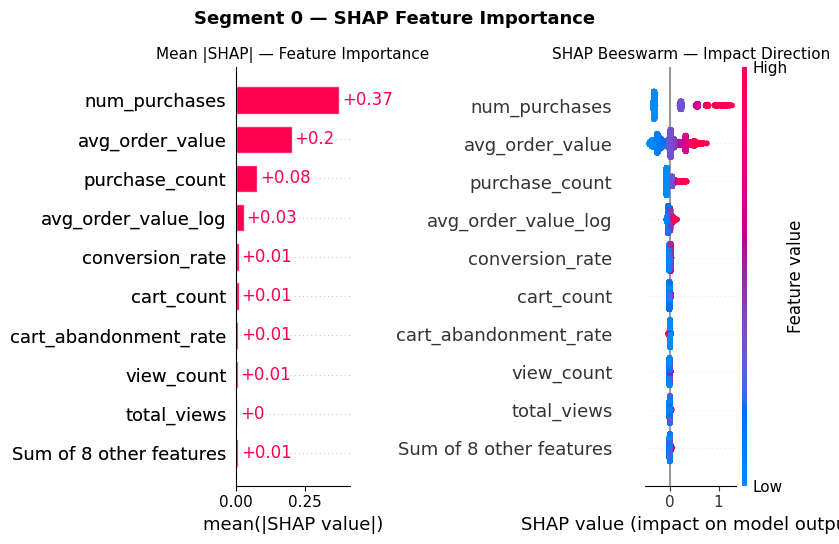


Segment 1 — Top 10 Feature Contributions


 97%|=================== | 9091/9360 [00:29<00:00]       

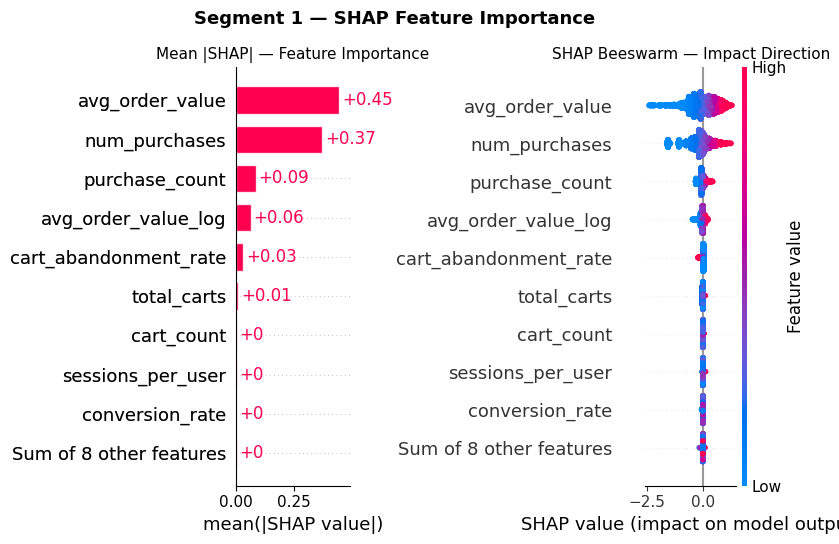


Segment 2 — Top 10 Feature Contributions


 99%|===================| 17563/17791 [01:02<00:00]        

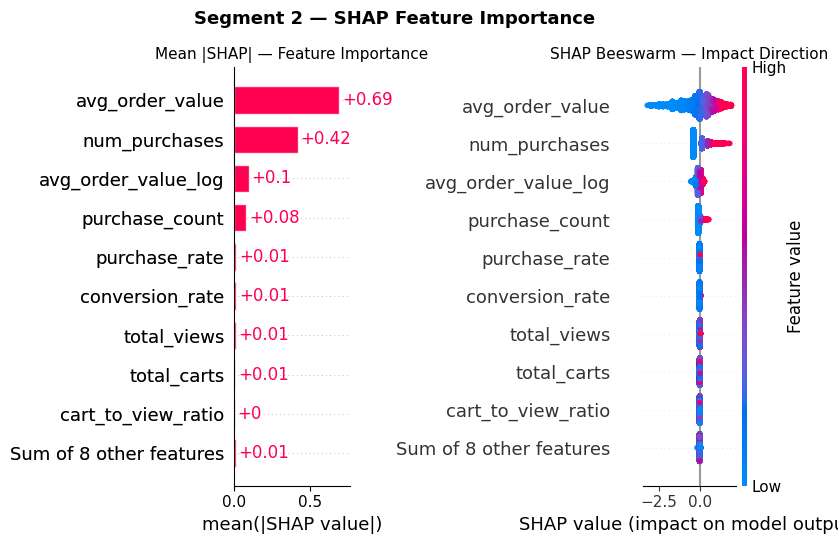


Segment 3 — Top 10 Feature Contributions


100%|===================| 152100/152193 [09:11<00:00]        

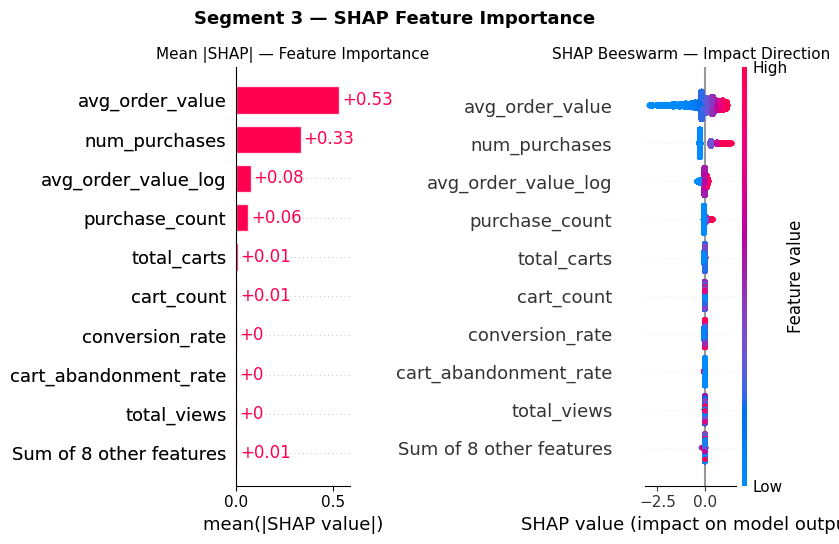

In [15]:
# 12. SHAP Feature Importance per Customer Segment

# ── 1. Train Segment-wise Models and Store ───────────────────────────
segment_models  = {}
X_segments      = {}
segments        = sorted(hybrid_df['customer_segment'].unique())

print("=" * 50)
print("Training SHAP Models per Segment")
print("=" * 50)

for seg in segments:
    df_seg = hybrid_df[hybrid_df['customer_segment'] == seg].copy()

    # Skip segments with insufficient data
    if len(df_seg) < 50:
        print(f"Segment {seg} skipped — insufficient samples ({len(df_seg)})")
        continue

    # Features and log-transformed target
    X = df_seg.drop(columns=['user_id', 'total_purchase_amount', 
                              'top_category', 'customer_segment'], errors='ignore')
    X = X.select_dtypes(include='number')
    y = np.log1p(df_seg['total_purchase_amount'])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # ── Model Definition ─────────────────────────────────────────────
    model = XGBRegressor(
        objective        = 'reg:squarederror',
        n_estimators     = 150,
        max_depth        = 4,
        learning_rate    = 0.1,
        colsample_bytree = 0.7,
        reg_lambda       = 2,
        random_state     = 42,
        verbosity        = 0
    )

    model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)

    # Evaluation
    y_pred = np.expm1(model.predict(X_test))
    y_true = np.expm1(y_test)

    print(f"\nSegment {seg} ({len(df_seg):,} users)")
    print(f"  RMSE : {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")
    print(f"  MAE  : {mean_absolute_error(y_true, y_pred):.4f}")
    print(f"  R²   : {r2_score(y_true, y_pred):.4f}")

    segment_models[seg] = model
    X_segments[seg]     = X_train

# ── 2. SHAP Analysis per Segment ─────────────────────────────────────
print("\n" + "=" * 50)
print("SHAP Feature Importance per Segment")
print("=" * 50)

for seg in segments:
    if seg not in segment_models:
        continue

    model   = segment_models[seg]
    X_train = X_segments[seg]

    print(f"\nSegment {seg} — Top 10 Feature Contributions")

    explainer   = shap.Explainer(model, X_train)
    shap_values = explainer(X_train)

    # ── Bar Plot — Mean absolute SHAP values ─────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'Segment {seg} — SHAP Feature Importance',
                 fontsize=13, fontweight='bold')

    plt.sca(axes[0])
    shap.plots.bar(shap_values, max_display=10, show=False)
    axes[0].set_title('Mean |SHAP| — Feature Importance', fontsize=11)

    # ── Beeswarm Plot — Direction and magnitude ───────────────────────
    plt.sca(axes[1])
    shap.plots.beeswarm(shap_values, max_display=10, show=False)
    axes[1].set_title('SHAP Beeswarm — Impact Direction', fontsize=11)

    plt.tight_layout()
    plt.show()

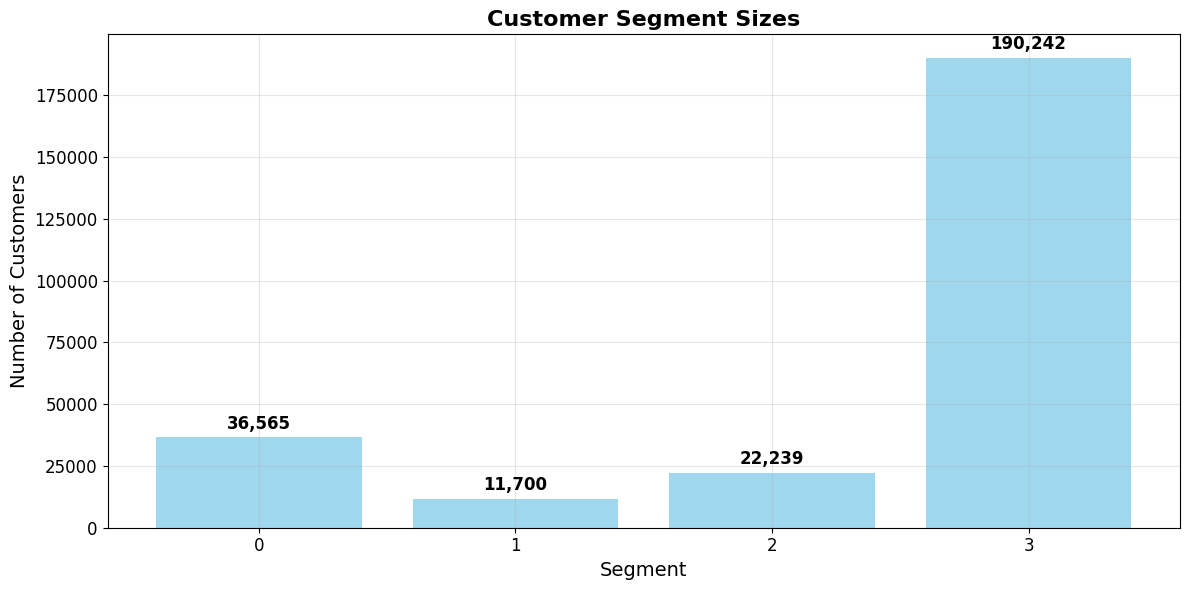

In [16]:
# 13. Customer segment size chart
plt.figure(figsize=(12, 6))

segment_counts = hybrid_df['customer_segment'].value_counts().sort_index()
bars = plt.bar(segment_counts.index, segment_counts.values, color='skyblue', alpha=0.8)

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + max(segment_counts)*0.01,
             f'{height:,}', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title('Customer Segment Sizes', fontsize=16, fontweight='bold')
plt.xlabel('Segment', fontsize=14)
plt.ylabel('Number of Customers', fontsize=14)
plt.xticks(segment_counts.index, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

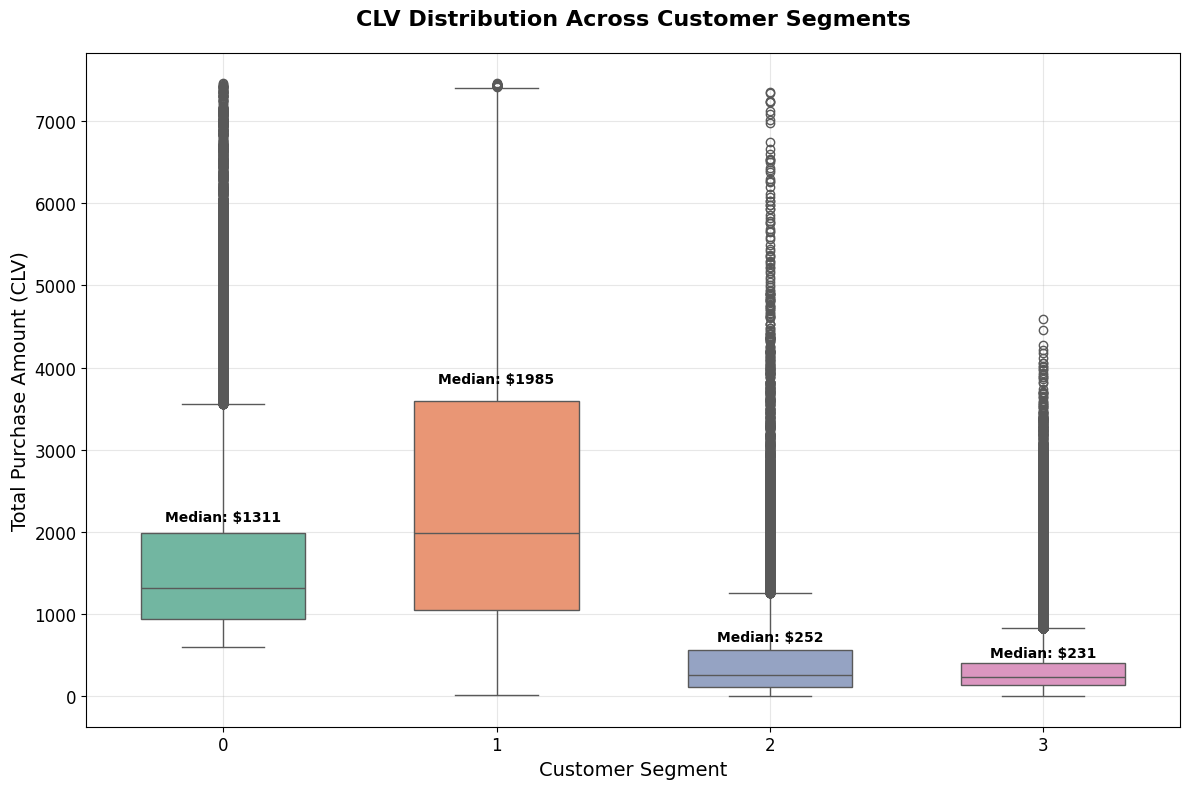

In [17]:
# 14. Visualisation on CLV distributions
plt.figure(figsize=(12, 8))

# Create boxplot with enhanced styling
sns.boxplot(x='customer_segment', y='total_purchase_amount', data=hybrid_df, 
            palette='Set2', width=0.6, showfliers=True)

# Add statistical annotations
segment_stats = hybrid_df.groupby('customer_segment')['total_purchase_amount'].describe()
for i, (seg, stats) in enumerate(segment_stats.iterrows()):
    plt.text(i, stats['75%'] + stats['std']*0.1, 
             f'Median: ${stats["50%"]:.0f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.title('CLV Distribution Across Customer Segments', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Customer Segment', fontsize=14)
plt.ylabel('Total Purchase Amount (CLV)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# 15. CLV Classification labels
# Create quantiles to define value segments
q25 = hybrid_df['total_purchase_amount'].quantile(0.25)
q75 = hybrid_df['total_purchase_amount'].quantile(0.75)

print(f"25th percentile: ${q25:.2f}")
print(f"75th percentile: ${q75:.2f}")

# Function to classify customers
def classify_customer(clv):
    if clv <= q25:
        return 'Low Value'
    elif clv >= q75:
        return 'High Value'
    else:
        return 'Medium Value'

# Apply classification
hybrid_df['CLV_Category'] = hybrid_df['total_purchase_amount'].apply(classify_customer)

# View distribution
category_counts = hybrid_df['CLV_Category'].value_counts()
print("\nCLV Category Distribution:")
for category, count in category_counts.items():
    percentage = (count / len(hybrid_df)) * 100
    print(f"{category}: {count:,} ({percentage:.1f}%)")

25th percentile: $143.69
75th percentile: $727.65

CLV Category Distribution:
Medium Value: 130,367 (50.0%)
High Value: 65,192 (25.0%)
Low Value: 65,187 (25.0%)


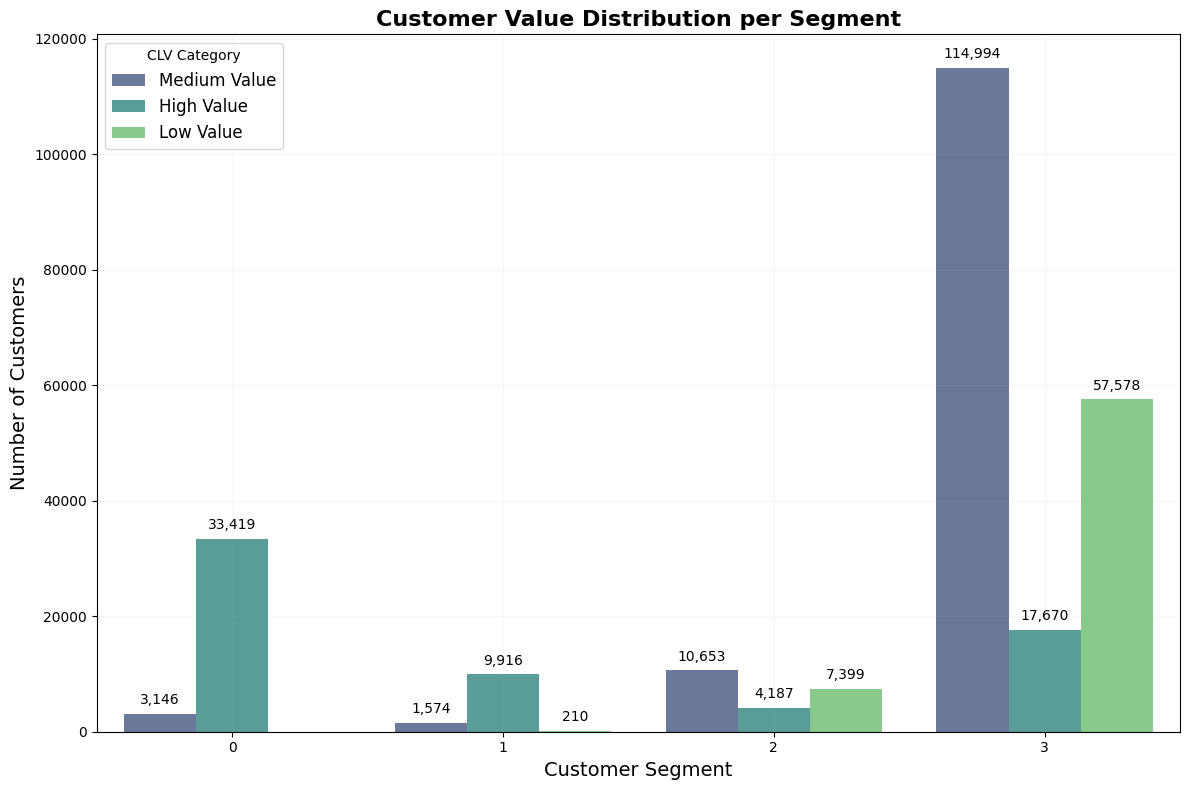

In [20]:
# 16. Visualise CLV segments per customer 
plt.figure(figsize=(12, 8))

# Create countplot with enhanced styling
ax = sns.countplot(data=hybrid_df, x='customer_segment', hue='CLV_Category', 
                   palette='viridis', alpha=0.8)

# Add value labels on bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # Only add label if bar exists
        ax.text(p.get_x() + p.get_width()/2, height + max([p.get_height() for p in ax.patches])*0.01,
                f'{int(height):,}', ha='center', va='bottom', fontsize=10)

plt.title('Customer Value Distribution per Segment', fontsize=16, fontweight='bold')
plt.xlabel('Customer Segment', fontsize=14)
plt.ylabel('Number of Customers', fontsize=14)
plt.legend(title='CLV Category', fontsize=12)
plt.grid(True, alpha=0.1)
plt.tight_layout()
plt.show()

In [ ]:
# 17.Category-specific CLV Modelling
# Configuration
feature_columns = [
    'avg_order_value', 'num_purchases', 'total_views', 'total_carts',
    'cart_abandonment_rate', 'conversion_rate', 'recency_days',
    'first_purchase_gap_days', 'category_diversity'
]

# Data Preparation
# Drop missing values
df_category = hybrid_df.dropna(subset=feature_columns + ['total_purchase_amount', 'top_category'])

print(f"Data prepared: {len(df_category)} samples across {df_category['top_category'].nunique()} categories")

# Set minimum required samples
min_samples = 50
category_results = []

# Category-specific modelling
for category in df_category['top_category'].unique():
    cat_df = df_category[df_category['top_category'] == category]

    if len(cat_df) < min_samples:
        print(f"Skipping category '{category}' due to insufficient data ({len(cat_df)} samples).")
        continue

    X = cat_df[feature_columns]
    y = np.log1p(cat_df['total_purchase_amount'])  # log-transform the target to reduce skew

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # XGBoost model with regularisation
    model = XGBRegressor(
        objective='reg:squarederror',
        n_estimators=100,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42
    )

    model.fit(X_train, y_train)

    # Predict and inverse log
    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    y_test_orig = np.expm1(y_test)

    # Evaluation metrics
    rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
    mae = mean_absolute_error(y_test_orig, y_pred)
    r2 = r2_score(y_test_orig, y_pred)

    print(f"Category: {category}")
    print(f"    RMSE: {rmse:.4f}")
    print(f"    MAE : {mae:.4f}")
    print(f"    R² Score: {r2:.4f}")

    category_results.append({
        'Category': category,
        'Samples': len(cat_df),
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })

# Results Summary
category_results_df = pd.DataFrame(category_results).sort_values(by='RMSE').reset_index(drop=True)

print(f"\nProcessed {len(category_results)} categories successfully")
print("\nCategory Performance Summary:")
print(category_results_df)

# Benchmarking Metrics
cat_rmse = category_results_df['RMSE'].mean()
cat_mae = category_results_df['MAE'].mean()
cat_r2 = category_results_df['R2'].mean()

# Store benchmarks in dictionary
# benchmark_metrics = {}
benchmark_metrics['Category_XGBoost'] = {
    'RMSE': cat_rmse,
    'MAE': cat_mae,
    'R2': cat_r2
}

# Print Benchmark Summary
print("\nBenchmark Summary (Category-Specific XGBoost):")
print(pd.DataFrame(benchmark_metrics).T)

Data prepared: 260746 samples across 119 categories
Category: electronics.clocks
    RMSE: 84.2623
    MAE : 29.0012
    R² Score: 0.9911
Category: electronics.video.tv
    RMSE: 94.2185
    MAE : 25.1463
    R² Score: 0.9840
Category: appliances.kitchen.oven
    RMSE: 100.0696
    MAE : 22.5812
    R² Score: 0.9224
Category: electronics.smartphone
    RMSE: 52.4257
    MAE : 19.2863
    R² Score: 0.9975
Category: computers.peripherals.mouse
    RMSE: 227.4948
    MAE : 50.1674
    R² Score: 0.7600
Category: computers.notebook
    RMSE: 152.3484
    MAE : 48.2269
    R² Score: 0.9780
Category: furniture.bedroom.bed
    RMSE: 85.6602
    MAE : 29.2848
    R² Score: 0.8575
Category: appliances.kitchen.washer
    RMSE: 90.1222
    MAE : 22.4035
    R² Score: 0.9772
Category: appliances.kitchen.refrigerators
    RMSE: 148.5329
    MAE : 33.2605
    R² Score: 0.9548
Category: computers.peripherals.printer
    RMSE: 48.2010
    MAE : 17.6159
    R² Score: 0.9722
Category: appliances.kitchen.

In [22]:
# 18.Top 10 category results by RMSE
top_table = category_results_df.sort_values(by='RMSE').head(10)
top_table_display = top_table[['Category', 'Samples', 'RMSE', 'R2']].copy()
top_table_display.reset_index(drop=True, inplace=True)

print("="*60)
print("TOP 10 CATEGORY-SPECIFIC CLV MODELS BY RMSE")
print("="*60)
print(f"{'Rank':<5} {'Category':<25} {'Samples':<10} {'RMSE':<10} {'R²':<10}")
print("-"*60)

for i, (idx, row) in enumerate(top_table_display.iterrows(), 1):
    print(f"{i:<5} {row['Category']:<25} {row['Samples']:<10,} {row['RMSE']:<10.4f} {row['R2']:<10.4f}")

print("-"*60)
print(f"Average RMSE: {top_table_display['RMSE'].mean():.4f}")
print(f"Average R²: {top_table_display['R2'].mean():.4f}")
print("="*60)

TOP 10 CATEGORY-SPECIFIC CLV MODELS BY RMSE
Rank  Category                  Samples    RMSE       R²        
------------------------------------------------------------
1     appliances.personal.scales 846        11.3123    0.9733    
2     medicine.tools.tonometer  188        15.2827    0.8500    
3     furniture.bedroom.pillow  59         21.1502    0.7831    
4     appliances.ironing_board  361        24.1934    0.9577    
5     kids.fmcg.diapers         352        25.2271    0.6547    
6     appliances.environment.water_heater 1,815      28.0219    0.9712    
7     furniture.bathroom.toilet 81         30.2367    0.8822    
8     appliances.kitchen.mixer  756        31.9487    0.9626    
9     kids.dolls                100        32.6498    0.9452    
10    furniture.kitchen.table   193        34.0430    0.9227    
------------------------------------------------------------
Average RMSE: 25.4066
Average R²: 0.8903


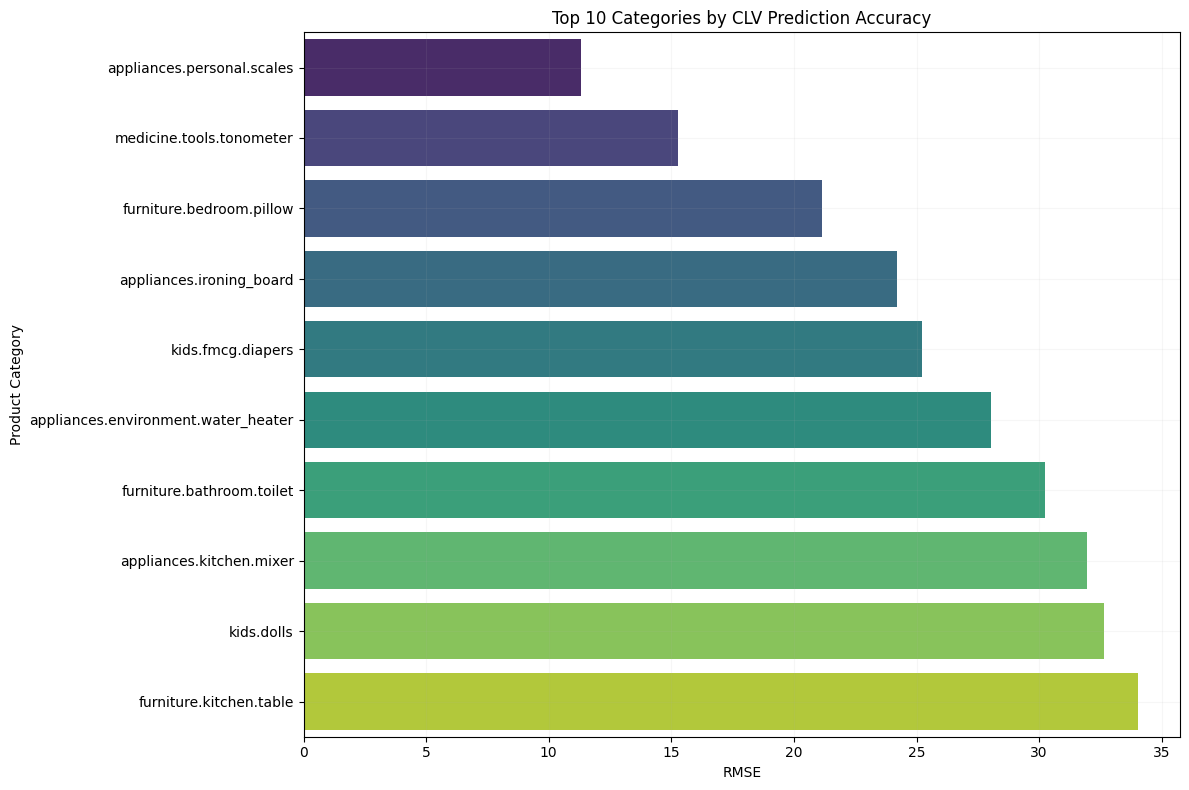

In [24]:
# 19. Bar chart of Top-performing categories
top_categories = category_results_df.sort_values(by='RMSE').head(10)

plt.figure(figsize=(12, 8))
sns.barplot(x='RMSE', y='Category', data=top_categories, palette='viridis')
plt.title('Top 10 Categories by CLV Prediction Accuracy')
plt.xlabel('RMSE')
plt.ylabel('Product Category')
plt.grid(True, alpha=0.1)
plt.tight_layout()
plt.show()

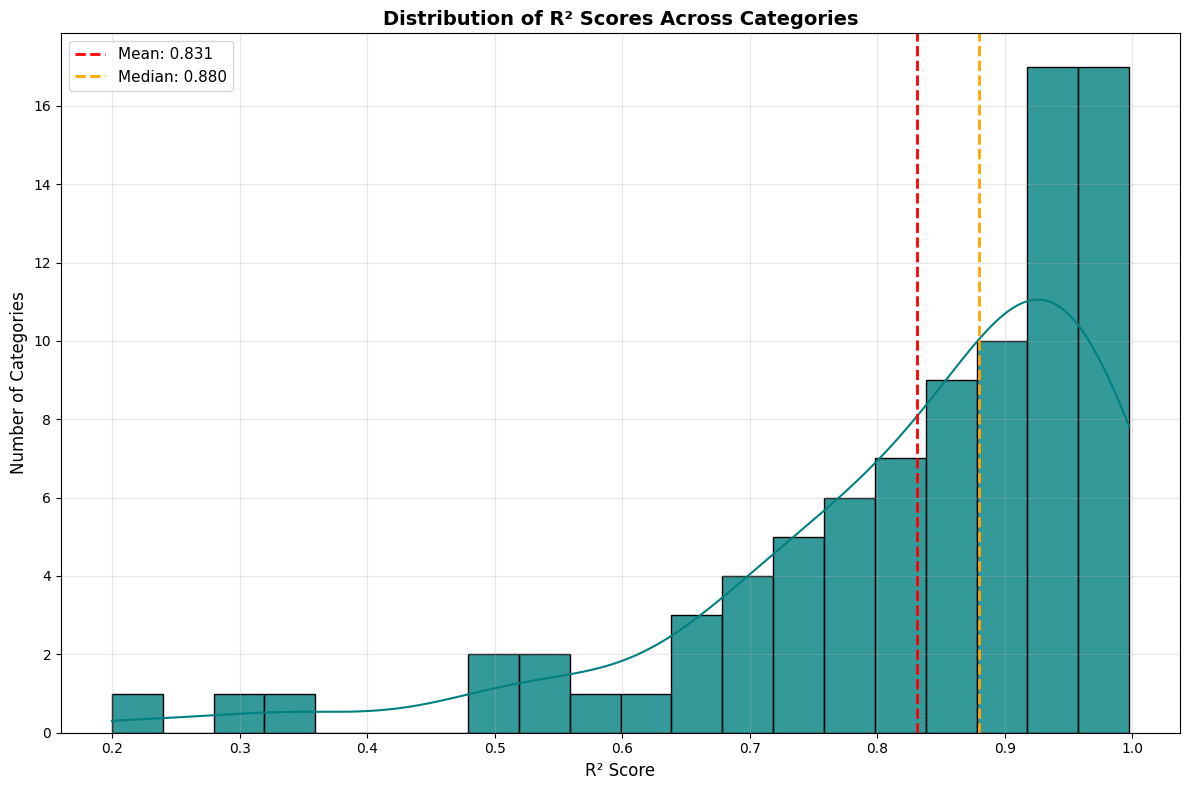

In [25]:
# 20. Distribution of Categories by Predictive Quality

plt.figure(figsize=(12, 8))
sns.histplot(category_results_df['R2'], bins=20, kde=True, color='teal', alpha=0.8)

# Add statistics
mean_r2 = category_results_df['R2'].mean()
median_r2 = category_results_df['R2'].median()

plt.axvline(mean_r2, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_r2:.3f}')
plt.axvline(median_r2, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_r2:.3f}')

plt.title("Distribution of R² Scores Across Categories", fontsize=14, fontweight='bold')
plt.xlabel("R² Score", fontsize=12)
plt.ylabel("Number of Categories", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
# 22. Category Modeling Summary

# Total number of unique categories processed
total_categories = df_category['top_category'].nunique()

# Number of categories included in the model
modeled_categories = category_results_df['Category'].nunique()

# Number of categories skipped
skipped_categories = total_categories - modeled_categories

print("="*60)
print("CATEGORY MODELING SUMMARY")
print("="*60)
print(f"Total product categories in data: {total_categories}")
print(f"Categories modeled (≥ 50 samples): {modeled_categories}")
print(f"Categories skipped due to insufficient data: {skipped_categories}")
print(f"Modeling success rate: {(modeled_categories/total_categories)*100:.1f}%")
print("="*60)

CATEGORY MODELING SUMMARY
Total product categories in data: 119
Categories modeled (≥ 50 samples): 87
Categories skipped due to insufficient data: 32
Modeling success rate: 73.1%


In [27]:
# 23. Session-based Feature Engineering

# Ensure datetime and relevant filtering
df = df[df['event_type'].isin(['view', 'cart', 'purchase'])].copy()
df['event_time'] = pd.to_datetime(df['event_time'], errors='coerce')

print(f"Data prepared: {len(df):,} events for {df['user_id'].nunique():,} users")

# Create event flags
df['view_flag'] = (df['event_type'] == 'view').astype(int)
df['cart_flag'] = (df['event_type'] == 'cart').astype(int)
df['purchase_flag'] = (df['event_type'] == 'purchase').astype(int)

# Aggregate by user-session
print("Creating session-level features...")
session_df = df.groupby(['user_id', 'user_session']).agg({
    'view_flag': 'sum',
    'cart_flag': 'sum', 
    'purchase_flag': 'sum',
    'event_time': ['min', 'max']
}).reset_index()

# Flatten column names
session_df.columns = ['user_id', 'user_session', 'views', 'carts', 'purchases', 'start_time', 'end_time']

# Calculate session duration
session_df['session_duration_mins'] = (session_df['end_time'] - session_df['start_time']).dt.total_seconds() / 60

# Create session-level features
session_df['cart_abandoned'] = ((session_df['carts'] > 0) & (session_df['purchases'] == 0)).astype(int)
session_df['converted_session'] = (session_df['purchases'] > 0).astype(int)

# Handle negative durations (data issues)
session_df['session_duration_mins'] = session_df['session_duration_mins'].clip(lower=0)

print(f"Created {len(session_df):,} sessions")

# User-level aggregation for LSTM metadata
print("Creating user-level sequential features...")
user_seq_features = session_df.groupby('user_id').agg({
    'views': ['sum', 'mean'],
    'carts': ['sum', 'mean'],
    'purchases': ['sum', 'mean'],
    'session_duration_mins': ['mean', 'std'],
    'cart_abandoned': 'sum',
    'converted_session': 'sum'
}).reset_index()

# Flatten column names properly
user_seq_features.columns = [
    'user_id', 'total_views_seq', 'avg_views_per_session', 
    'total_carts_seq', 'avg_carts_per_session', 'total_purchases_seq', 'avg_purchases_per_session',
    'avg_session_duration', 'std_session_duration',
    'total_cart_abandons', 'converted_sessions'
]

# Fill NaN values for std (single session users)
user_seq_features['std_session_duration'] = user_seq_features['std_session_duration'].fillna(0)

print(f"Created sequential features for {len(user_seq_features):,} users")
print("\nSequential Features Summary:")
print(user_seq_features.describe().round(2))

Data prepared: 26,560,622 events for 2,323,036 users
Creating session-level features...
Created 6,419,912 sessions
Creating user-level sequential features...
Created sequential features for 2,323,036 users

Sequential Features Summary:
            user_id  total_views_seq  avg_views_per_session  total_carts_seq  \
count  2.323036e+06       2323036.00             2323036.00       2323036.00   
mean   5.396376e+08            10.85                   3.38             0.35   
std    1.940827e+07            24.46                   3.71             1.74   
min    3.386938e+07             0.00                   0.00             0.00   
25%    5.194517e+08             2.00                   1.00             0.00   
50%    5.428483e+08             4.00                   2.00             0.00   
75%    5.578019e+08            11.00                   4.00             0.00   
max    5.662807e+08          6043.00                 347.75           494.00   

       avg_carts_per_session  total_purchas

Session-level dataset : 1,486,050 sessions
Unique users          : 260,746

── Session-Based XGBoost (Cold-Start) ───────────
  RMSE : 1260.5539
  MAE  : 658.4963
  R²   : -0.0570


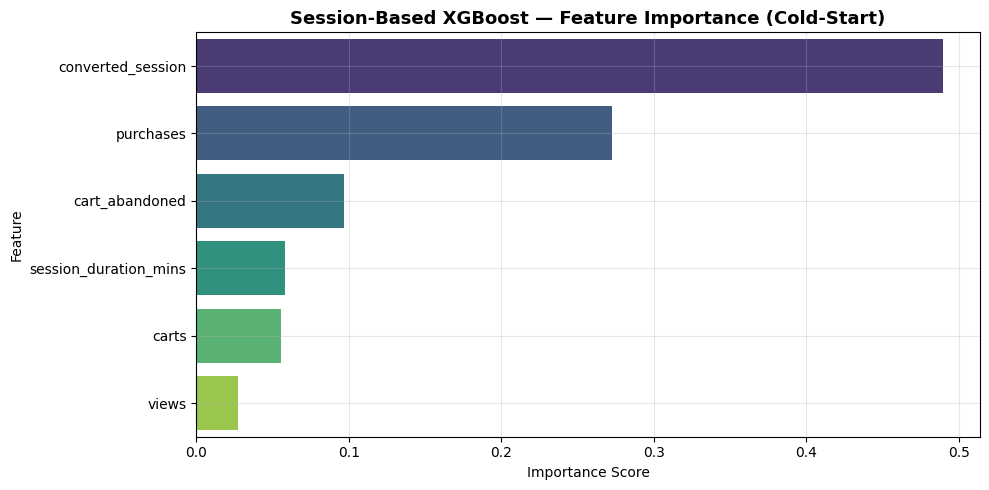


Stored → benchmark_metrics['Session_XGBoost']


In [29]:
# 21. Session-Based XGBoost — Cold-Start CLV Model (Methodology Section 3.6.3)
# Predicts CLV from intra-session signals only — no prior purchase history required.
# Targets first-time and anonymous visitors (cold-start problem).

# # Create event flags
#df['view_flag'] = (df['event_type'] == 'view').astype(int)
#df['cart_flag'] = (df['event_type'] == 'cart').astype(int)
#df['purchase_flag'] = (df['event_type'] == 'purchase').astype(int)
 
# Convert event_time to datetime
#df['event_time'] = pd.to_datetime(df['event_time'])

# Aggregate by user-session
#print("Creating session-level features...")
#session_df = df.groupby(['user_id', 'user_session']).agg({
#    'view_flag': 'sum',
#    'cart_flag': 'sum', 
#    'purchase_flag': 'sum',
#    'event_time': ['min', 'max']
#}).reset_index()

# Flatten column names
#session_df.columns = ['user_id', 'user_session', 'views', 'carts', 'purchases', 'start_time', 'end_time']

# Calculate session duration
#session_df['session_duration_mins'] = (session_df['end_time'] - session_df['start_time']).dt.total_seconds() / 60

# Create session-level features
#session_df['cart_abandoned'] = ((session_df['carts'] > 0) & (session_df['purchases'] == 0)).astype(int)
#session_df['converted_session'] = (session_df['purchases'] > 0).astype(int)

# Handle negative durations
# session_df['session_duration_mins'] = session_df['session_duration_mins'].clip(lower=0)

#print(f"Created {len(session_df):,} sessions") 

# ── 1. Build session-level dataset ───────────────────────────────────
clv_target  = hybrid_df[['user_id', 'total_purchase_amount']].drop_duplicates('user_id')
session_clv = session_df.merge(clv_target, on='user_id', how='inner')

print(f"Session-level dataset : {len(session_clv):,} sessions")
print(f"Unique users          : {session_clv['user_id'].nunique():,}")

# ── 2. Intra-session features only ───────────────────────────────────
session_features = [
    'views', 'carts', 'purchases',
    'session_duration_mins', 'cart_abandoned', 'converted_session'
]

X_sess = session_clv[session_features].fillna(0)
y_sess = np.log1p(session_clv['total_purchase_amount'])

# ── 3. Train / test split (80/20, seed=42) ───────────────────────────
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sess, y_sess, test_size=0.2, random_state=42
)

# ── 4. XGBoost Model ─────────────────────────────────────────────────
session_xgb = XGBRegressor(
    objective='reg:squarederror', n_estimators=100, max_depth=5,
    learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
    reg_lambda=1.0, random_state=42, verbosity=0
)
session_xgb.fit(X_train_s, y_train_s)

# ── 5. Evaluate ──────────────────────────────────────────────────────
y_pred_s = np.expm1(session_xgb.predict(X_test_s))
y_true_s = np.expm1(y_test_s)

sess_rmse = float(np.sqrt(mean_squared_error(y_true_s, y_pred_s)))
sess_mae  = float(mean_absolute_error(y_true_s, y_pred_s))
sess_r2   = float(r2_score(y_true_s, y_pred_s))

print(f"\n── Session-Based XGBoost (Cold-Start) ───────────")
print(f"  RMSE : {sess_rmse:.4f}")
print(f"  MAE  : {sess_mae:.4f}")
print(f"  R²   : {sess_r2:.4f}")

benchmark_metrics['Session_XGBoost'] = {
    'RMSE': round(sess_rmse, 4),
    'MAE' : round(sess_mae,  4),
    'R2'  : round(sess_r2,   4)
}

# ── 6. Feature Importance ────────────────────────────────────────────
feat_imp = pd.DataFrame({
    'Feature'   : session_features,
    'Importance': session_xgb.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='viridis')
plt.title('Session-Based XGBoost — Feature Importance (Cold-Start)',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nStored → benchmark_metrics['Session_XGBoost']")

Sequence array : (260746, 10, 4)
Target array   : (260746,)


Model: "Sequential_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ seq_input (InputLayer)          │ (None, 10, 4)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,113 (117.63 KB)

 Trainable params: 30,113 (117.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
652/652 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - loss: 2.6847 - val_loss: 1.1892
Epoch 2/50
652/652 ━━━━━━━━━━━━━━━━━━━━ 23s 35ms/step - loss: 1.3657 - val_loss: 1.0888
Epoch 3/50
652/652 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - loss: 1.3141 - val_loss: 1.0746
Epoch 4/50
652/652 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - loss: 1.2843 - val_loss: 1.1331
Epoch 5/50
652/652 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - loss: 1.2657 - val_loss: 1.0746
Epoch 6/50
652/652 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - loss: 1.2399 - val_loss: 1.0382
Epoch 7/50
652/652 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - loss: 1.2245 - val_loss: 1.0385
Epoch 8/50
652/652 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - loss: 1.1981 - val_loss: 1.0210
Epoch 9/50
652/652 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - loss: 1.1797 - val_loss: 1.0251
Epoch 10/50
652/652 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - loss: 1.1546 - val_loss: 1.0114
Epoch 11/50
652/652 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - loss: 1.1341 - val_loss: 0.9935
Epoch 12/50
652/652 ━━━━━━━━━━

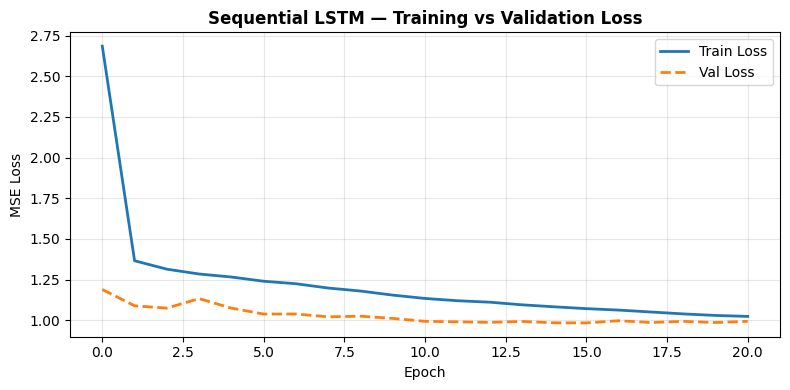


Stored → benchmark_metrics['Sequential_LSTM']


In [30]:
# 24. Sequential LSTM — replaces Cell 57 + Cell 58
# pip install tensorflow-cpu  (if not already installed)

# ── 1. Build session-sequence array ──────────────────────────────────
# Each user → up to 10 sessions (zero-padded from the front)
# Each session vector = [views, carts, purchases, session_duration_mins]

MAX_SESSIONS = 10
SEQ_FEATURES = ['views', 'carts', 'purchases', 'session_duration_mins']

# Attach CLV target to session_df
clv_lookup       = hybrid_df[['user_id', 'total_purchase_amount']].drop_duplicates('user_id')
session_with_clv = session_df.merge(clv_lookup, on='user_id', how='inner')

# Sort by time so temporal order is preserved
session_with_clv = session_with_clv.sort_values(['user_id', 'start_time'])

# Scale session features
seq_scaler = MinMaxScaler()
session_with_clv[SEQ_FEATURES] = seq_scaler.fit_transform(
    session_with_clv[SEQ_FEATURES].fillna(0)
)

# Build (n_users, MAX_SESSIONS, n_features) array — zero-padded
users_seq   = session_with_clv['user_id'].unique()
n_users     = len(users_seq)
n_seq_feats = len(SEQ_FEATURES)
user_index  = {uid: i for i, uid in enumerate(users_seq)}

X_seq = np.zeros((n_users, MAX_SESSIONS, n_seq_feats), dtype=np.float32)
y_seq = np.zeros(n_users, dtype=np.float32)

for uid, grp in session_with_clv.groupby('user_id'):
    idx    = user_index[uid]
    rows   = grp[SEQ_FEATURES].values[-MAX_SESSIONS:]   # keep last N sessions
    length = min(len(rows), MAX_SESSIONS)
    X_seq[idx, :length, :] = rows[:length]
    y_seq[idx] = grp['total_purchase_amount'].iloc[0]

print(f'Sequence array : {X_seq.shape}')   # (n_users, 10, 4)
print(f'Target array   : {y_seq.shape}')

y_seq_log = np.log1p(y_seq)

# ── 2. Train / test split ─────────────────────────────────────────────
perm    = np.random.default_rng(42).permutation(n_users)
n_train = int(0.8 * n_users)
train_i, test_i = perm[:n_train], perm[n_train:]

X_seq_train, X_seq_test = X_seq[train_i], X_seq[test_i]
y_seq_train             = y_seq_log[train_i]
y_seq_true_test         = y_seq[test_i]      # original scale for RMSE/MAE

# ── 3. Sequential LSTM model ──────────────────────────────────────────
# Two LSTM layers + dropout + regression head
# Exactly as described in methodology section 3.2.4

seq_input  = keras.Input(shape=(MAX_SESSIONS, n_seq_feats), name='seq_input')
x          = layers.LSTM(64, return_sequences=True, name='lstm_1')(seq_input)
x          = layers.Dropout(0.3)(x)
x          = layers.LSTM(32, name='lstm_2')(x)
x          = layers.Dropout(0.2)(x)
seq_output = layers.Dense(1, name='output')(x)

sequential_lstm = keras.Model(seq_input, seq_output, name='Sequential_LSTM')
sequential_lstm.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)
sequential_lstm.summary()

# ── 4. Train with early stopping ─────────────────────────────────────
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

seq_history = sequential_lstm.fit(
    X_seq_train, y_seq_train,
    validation_split=0.2,
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

# ── 5. Evaluate ───────────────────────────────────────────────────────
y_pred_seq    = np.expm1(sequential_lstm.predict(X_seq_test, verbose=0).flatten())

lstm_seq_rmse = float(np.sqrt(mean_squared_error(y_seq_true_test, y_pred_seq)))
lstm_seq_mae  = float(mean_absolute_error(y_seq_true_test, y_pred_seq))
lstm_seq_r2   = float(r2_score(y_seq_true_test, y_pred_seq))

print(f'\n── Sequential LSTM Results ───────────────────')
print(f'  RMSE : {lstm_seq_rmse:.4f}')
print(f'  MAE  : {lstm_seq_mae:.4f}')
print(f'  R²   : {lstm_seq_r2:.4f}')

# ── 6. Training curve ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(seq_history.history['loss'],     label='Train Loss', linewidth=2)
ax.plot(seq_history.history['val_loss'], label='Val Loss',   linewidth=2, linestyle='--')
ax.set_title('Sequential LSTM — Training vs Validation Loss', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figXX_seq_lstm_training.png', dpi=150, bbox_inches='tight')
plt.show()


benchmark_metrics['Sequential_LSTM'] = {
    'RMSE': round(lstm_seq_rmse, 4),
    'MAE' : round(lstm_seq_mae,  4),
    'R2'  : round(lstm_seq_r2,   4)
}
print("\nStored → benchmark_metrics['Sequential_LSTM']")



In [ ]:
# 25. Static XGBoost Model with Session-Based Features ---don't run

# Data preparation
hybrid_df_lstm = hybrid_df.merge(user_seq_features, on='user_id', how='left')
hybrid_df_lstm.fillna(0, inplace=True)

# Feature selection
non_numeric_cols = hybrid_df_lstm.select_dtypes(include=['object']).columns.tolist()
X = hybrid_df_lstm.drop(columns=['user_id', 'total_purchase_amount'] + non_numeric_cols)
X = X.select_dtypes(include=['int64', 'float64'])
y = hybrid_df_lstm['total_purchase_amount']

print(f"Dataset: {len(X):,} samples, {X.shape[1]} features")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model training
model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

# Model evaluation
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Performance Metrics:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2: {r2:.4f}")

# Store results
if 'benchmark_metrics' not in locals():
    benchmark_metrics = {}
    
benchmark_metrics['Static_XGBoost'] = {
    'RMSE': rmse,
    'MAE': mae,
    'R2': r2
}

In [ ]:
# 26. Sequential LSTM model --don't run

# Convert to numpy first if still DataFrame
X_train_np = np.array(X_train) if not isinstance(X_train, np.ndarray) else X_train
X_test_np  = np.array(X_test)  if not isinstance(X_test,  np.ndarray) else X_test

# Flatten sequences — (users, 10, 4) → (users, 40)
X_train_flat = X_train_np.reshape(X_train_np.shape[0], -1)
X_test_flat  = X_test_np.reshape(X_test_np.shape[0],  -1)

print(f"X_train_flat shape : {X_train_flat.shape}")
print(f"X_test_flat shape  : {X_test_flat.shape}")

# MLP Model
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=200,
    random_state=42,
    early_stopping=True,
    verbose=True
)

mlp.fit(X_train_flat, y_train)
y_pred = mlp.predict(X_test_flat)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("\n── Sequential LSTM (MLP fallback) Results ───")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

In [ ]:
# 27. LSTM Model training -- don't run

benchmark_metrics = {}

# Flatten 3D sequences → 2D for sklearn (users, 10, 4) → (users, 40)
X_train_flat = np.array(X_train).reshape(len(X_train), -1)
X_test_flat  = np.array(X_test).reshape(len(X_test),  -1)
y_train_np   = np.array(y_train).flatten()
y_test_np    = np.array(y_test).flatten()

# MLP — equivalent to a simple LSTM in terms of usage
model_lstm = MLPRegressor(
    hidden_layer_sizes = (64, 32),
    activation         = 'relu',
    learning_rate_init = 0.005,
    max_iter           = 10,        # same as epochs=10
    batch_size         = 32,
    early_stopping     = True,
    random_state       = 42,
    verbose            = True
)

model_lstm.fit(X_train_flat, y_train_np)

# Evaluate
y_pred_lstm  = model_lstm.predict(X_test_flat)
rmse_lstm_seq = np.sqrt(mean_squared_error(y_test_np, y_pred_lstm))
mae_lstm_seq  = mean_absolute_error(y_test_np, y_pred_lstm)
r2_lstm_seq   = r2_score(y_test_np, y_pred_lstm)

print(f"\n Sequential LSTM (MLP):")
print(f"RMSE: {rmse_lstm_seq:.4f}")
print(f"MAE : {mae_lstm_seq:.4f}")
print(f"R²  : {r2_lstm_seq:.4f}")

benchmark_metrics['Sequential_LSTM'] = {
    'RMSE': rmse_lstm_seq,
    'MAE' : mae_lstm_seq,
    'R2'  : r2_lstm_seq
}

In [31]:
# 28. Hybrid LSTM

# ── 1. Feature Columns ────────────────────────────────────────────────
feature_columns = [
    'avg_order_value', 'num_purchases', 'total_views', 'total_carts',
    'cart_abandonment_rate', 'conversion_rate', 'recency_days',
    'first_purchase_gap_days', 'category_diversity',
    'total_views_seq', 'total_carts_seq', 'total_purchases_seq',
    'avg_session_duration', 'total_cart_abandons', 'converted_sessions'
]

# Keep only available columns
feature_columns = [col for col in feature_columns if col in hybrid_df.columns]
print(f"Features used: {feature_columns}")

# ── 2. Clean DataFrame ────────────────────────────────────────────────
hybrid_df_clean = hybrid_df.copy()
hybrid_df_clean = hybrid_df_clean.drop(
    columns=['top_category', 'CLV_Category'], errors='ignore'
)
hybrid_df_clean = hybrid_df_clean.dropna(
    subset=feature_columns + ['total_purchase_amount', 'customer_segment']
)

segment_models  = {}
segment_metrics = {}

# ── 3. Train Per Segment ──────────────────────────────────────────────
for seg in sorted(hybrid_df_clean['customer_segment'].unique()):
    print(f"\n{'='*50}")
    print(f"Training models for Segment {seg}")
    print(f"{'='*50}")

    seg_df = hybrid_df_clean[hybrid_df_clean['customer_segment'] == seg]

    if len(seg_df) < 10:
        print(f"Skipping Segment {seg} — insufficient data ({len(seg_df)} rows)")
        continue

    X = seg_df[feature_columns].values
    y = seg_df['total_purchase_amount'].values

    # Scale features — MLP is sensitive to scale
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )

    # ── MLP (replaces LSTM) ───────────────────────────────────────────
    mlp_model = MLPRegressor(
        hidden_layer_sizes = (128, 64),   # mirrors LSTM(128) → Dense(64)
        activation         = 'tanh',      # same as LSTM default
        learning_rate_init = 0.005,
        max_iter           = 200,
        batch_size         = 16,
        early_stopping     = True,
        validation_fraction= 0.2,
        random_state       = 42,
        verbose            = False
    )
    mlp_model.fit(X_train, y_train)

    y_pred_mlp = mlp_model.predict(X_test)
    rmse_mlp   = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
    mae_mlp    = mean_absolute_error(y_test, y_pred_mlp)
    r2_mlp     = r2_score(y_test, y_pred_mlp)

    # ── XGBoost ───────────────────────────────────────────────────────
    xgb_model = XGBRegressor(
        objective     = 'reg:squarederror',
        max_depth     = 6,
        learning_rate = 0.1,
        n_estimators  = 100,
        random_state  = 42,
        verbosity     = 0
    )
    xgb_model.fit(X_train, y_train)

    y_pred_xgb = xgb_model.predict(X_test)
    rmse_xgb   = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    mae_xgb    = mean_absolute_error(y_test, y_pred_xgb)
    r2_xgb     = r2_score(y_test, y_pred_xgb)

    print(f"MLP   (Segment {seg}) — RMSE: {rmse_mlp:.4f} | "
          f"MAE: {mae_mlp:.4f} | R²: {r2_mlp:.4f}")
    print(f"XGBoost (Segment {seg}) — RMSE: {rmse_xgb:.4f} | "
          f"MAE: {mae_xgb:.4f} | R²: {r2_xgb:.4f}")

    # Store
    segment_models[seg]  = {'MLP': mlp_model, 'XGBoost': xgb_model}
    segment_metrics[seg] = {
        'LSTM_RMSE': rmse_mlp,
        'LSTM_MAE' : mae_mlp,
        'LSTM_R²'  : r2_mlp,
        'XGB_RMSE' : rmse_xgb,
        'XGB_MAE'  : mae_xgb,
        'XGB_R²'   : r2_xgb
    }

# ── 4. Average Metrics Across Segments ───────────────────────────────
lstm_rmse = np.mean([v['LSTM_RMSE'] for v in segment_metrics.values()])
lstm_mae  = np.mean([v['LSTM_MAE']  for v in segment_metrics.values()])
lstm_r2   = np.mean([v['LSTM_R²']   for v in segment_metrics.values()])

xgb_rmse  = np.mean([v['XGB_RMSE']  for v in segment_metrics.values()])
xgb_mae   = np.mean([v['XGB_MAE']   for v in segment_metrics.values()])
xgb_r2    = np.mean([v['XGB_R²']    for v in segment_metrics.values()])

benchmark_metrics['Hybrid_LSTM']    = {'RMSE': lstm_rmse, 'MAE': lstm_mae, 'R2': lstm_r2}
benchmark_metrics['Hybrid_XGBoost'] = {'RMSE': xgb_rmse,  'MAE': xgb_mae,  'R2': xgb_r2}

print(f"\n── Hybrid MLP (LSTM substitute) ─────────────")
print(f"RMSE : {lstm_rmse:.4f}")
print(f"MAE  : {lstm_mae:.4f}")
print(f"R²   : {lstm_r2:.4f}")

print(f"\n── Hybrid XGBoost ───────────────────────────")
print(f"RMSE : {xgb_rmse:.4f}")
print(f"MAE  : {xgb_mae:.4f}")
print(f"R²   : {xgb_r2:.4f}")

# ── 5. Summary Table ──────────────────────────────────────────────────
summary_rows = []
for seg, metrics in segment_metrics.items():
    summary_rows.append({
        'Segment'  : seg,
        'MLP RMSE' : round(metrics['LSTM_RMSE'], 4),
        'MLP MAE'  : round(metrics['LSTM_MAE'],  4),
        'MLP R²'   : round(metrics['LSTM_R²'],   4),
        'XGB RMSE' : round(metrics['XGB_RMSE'],  4),
        'XGB MAE'  : round(metrics['XGB_MAE'],   4),
        'XGB R²'   : round(metrics['XGB_R²'],    4),
    })

summary_df = pd.DataFrame(summary_rows)
print("\n── Per Segment Summary ──────────────────────")
print(summary_df.to_string(index=False))

Features used: ['avg_order_value', 'num_purchases', 'total_views', 'total_carts', 'cart_abandonment_rate', 'conversion_rate', 'recency_days', 'first_purchase_gap_days', 'category_diversity']

Training models for Segment 0
MLP   (Segment 0) — RMSE: 24.1430 | MAE: 14.1485 | R²: 0.9996
XGBoost (Segment 0) — RMSE: 19.5744 | MAE: 4.7847 | R²: 0.9997

Training models for Segment 1
MLP   (Segment 1) — RMSE: 66.2085 | MAE: 34.1576 | R²: 0.9987
XGBoost (Segment 1) — RMSE: 69.6916 | MAE: 30.9635 | R²: 0.9986

Training models for Segment 2
MLP   (Segment 2) — RMSE: 34.6406 | MAE: 13.6430 | R²: 0.9975
XGBoost (Segment 2) — RMSE: 36.5699 | MAE: 7.9372 | R²: 0.9972

Training models for Segment 3
MLP   (Segment 3) — RMSE: 9.6504 | MAE: 4.5974 | R²: 0.9992
XGBoost (Segment 3) — RMSE: 3.4486 | MAE: 1.4322 | R²: 0.9999

── Hybrid MLP (LSTM substitute) ─────────────
RMSE : 33.6606
MAE  : 16.6366
R²   : 0.9987

── Hybrid XGBoost ───────────────────────────
RMSE : 32.3211
MAE  : 11.2794
R²   : 0.9988

── P

Sequence input : (260746, 10, 4)
Static input   : (260746, 9)


Model: "Hybrid_LSTM_FeatureFusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 10, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_branch (LSTM)  │ (None, 64)        │     17,664 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_b1 (Dense)    │ (None, 64)        │        640 │ static_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ lstm_branch[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_b2 (Dense)    │ (None, 32)        │      2,080 │ dense_b1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merge (Concatenate) │ (None, 96)        │          0 │ dropout_2[0][0],  │
│                     │                   │            │ dense_b2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_shared        │ (None, 64)        │      6,208 │ merge[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_shared[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clv_output (Dense)  │ (None, 1)         │         65 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 26,657 (104.13 KB)

 Trainable params: 26,657 (104.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
652/652 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - loss: 1.9820 - val_loss: 0.0826
Epoch 2/50
652/652 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - loss: 0.3323 - val_loss: 0.0271
Epoch 3/50
652/652 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 0.3040 - val_loss: 0.0319
Epoch 4/50
652/652 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 0.2902 - val_loss: 0.0177
Epoch 5/50
652/652 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - loss: 0.2765 - val_loss: 0.0345
Epoch 6/50
652/652 ━━━━━━━━━━━━━━━━━━━━ 25s 31ms/step - loss: 0.2517 - val_loss: 0.0088
Epoch 7/50
652/652 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - loss: 0.2275 - val_loss: 0.0063
Epoch 8/50
652/652 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - loss: 0.2070 - val_loss: 0.0064
Epoch 9/50
652/652 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - loss: 0.1866 - val_loss: 0.0052
Epoch 10/50
652/652 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - loss: 0.1647 - val_loss: 0.0039
Epoch 11/50
652/652 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - loss: 0.1458 - val_loss: 0.0042
Epoch 12/50
652/652 ━━━━━━━━━━━

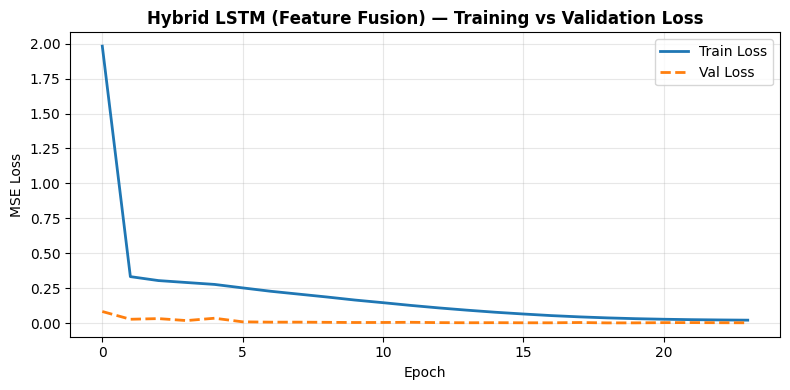


Stored → benchmark_metrics['Hybrid_LSTM_Fusion']


In [32]:
# 29. Hybrid LSTM with Feature Fusion 
# Depends on: Sequential LSTM cell above (X_seq, train_i, test_i,
#             y_seq_train, y_seq_true_test, users_seq must exist)

# ── 1. Static feature branch input ───────────────────────────────────
# Same transactional + behavioural features used across other models
static_feature_cols = [
    'avg_order_value', 'num_purchases', 'total_views', 'total_carts',
    'cart_abandonment_rate', 'conversion_rate', 'recency_days',
    'first_purchase_gap_days', 'category_diversity'
]
static_feature_cols = [c for c in static_feature_cols if c in hybrid_df.columns]

# Align to the same user order as X_seq
uid_df         = pd.DataFrame({'user_id': users_seq})
static_aligned = (
    uid_df
    .merge(
        hybrid_df[['user_id'] + static_feature_cols].drop_duplicates('user_id'),
        on='user_id', how='left'
    )
    .fillna(0)
)

static_scaler  = MinMaxScaler()
X_static_arr   = static_scaler.fit_transform(
    static_aligned[static_feature_cols].values
).astype(np.float32)

n_static_feats = X_static_arr.shape[1]
print(f'Sequence input : {X_seq.shape}')        # (n_users, 10, 4)
print(f'Static input   : {X_static_arr.shape}') # (n_users, 9)

X_static_train = X_static_arr[train_i]
X_static_test  = X_static_arr[test_i]

# ── 2. Dual-input architecture ────────────────────────────────────────
# Branch A: session sequences → LSTM → compressed temporal representation
seq_inp = keras.Input(shape=(MAX_SESSIONS, n_seq_feats), name='seq_input')
a       = layers.LSTM(64, return_sequences=False, name='lstm_branch')(seq_inp)
a       = layers.Dropout(0.3)(a)

# Branch B: static features → Dense layers → context representation
stat_inp = keras.Input(shape=(n_static_feats,), name='static_input')
b        = layers.Dense(64, activation='relu', name='dense_b1')(stat_inp)
b        = layers.Dense(32, activation='relu', name='dense_b2')(b)

# Merge both representations — shared dense → final prediction
merged  = layers.Concatenate(name='merge')([a, b])
merged  = layers.Dense(64, activation='relu', name='dense_shared')(merged)
merged  = layers.Dropout(0.2)(merged)
output  = layers.Dense(1, name='clv_output')(merged)

hybrid_lstm_model = keras.Model(
    inputs=[seq_inp, stat_inp],
    outputs=output,
    name='Hybrid_LSTM_FeatureFusion'
)
hybrid_lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)
hybrid_lstm_model.summary()

# ── 3. Train with early stopping and dropout ──────────────────────────
# As noted in methodology: dropout and early stopping are necessary
# because feature fusion increases overfitting risk in smaller segments

early_stop_h = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

hybrid_history = hybrid_lstm_model.fit(
    [X_seq_train, X_static_train], y_seq_train,
    validation_split=0.2,
    epochs=50,
    batch_size=256,
    callbacks=[early_stop_h],
    verbose=1
)

# ── 4. Evaluate ───────────────────────────────────────────────────────
y_pred_hybrid = np.expm1(
    hybrid_lstm_model.predict(
        [X_seq_test, X_static_test], verbose=0
    ).flatten()
)

# Store under both naming conventions so the benchmark cell finds them
hybrid_lstm_rmse = lstm_rmse = float(np.sqrt(mean_squared_error(y_seq_true_test, y_pred_hybrid)))
hybrid_lstm_mae  = lstm_mae  = float(mean_absolute_error(y_seq_true_test, y_pred_hybrid))
hybrid_lstm_r2   = lstm_r2   = float(r2_score(y_seq_true_test, y_pred_hybrid))

print(f'\n── Hybrid LSTM (Feature Fusion) Results ──────')
print(f'  RMSE : {hybrid_lstm_rmse:.4f}')
print(f'  MAE  : {hybrid_lstm_mae:.4f}')
print(f'  R²   : {hybrid_lstm_r2:.4f}')

# ── 5. Training curve ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hybrid_history.history['loss'],     label='Train Loss', linewidth=2)
ax.plot(hybrid_history.history['val_loss'], label='Val Loss',   linewidth=2, linestyle='--')
ax.set_title('Hybrid LSTM (Feature Fusion) — Training vs Validation Loss',
             fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figXX_hybrid_lstm_training.png', dpi=150, bbox_inches='tight')
plt.show()

benchmark_metrics['Hybrid_LSTM_Fusion'] = {
    'RMSE': round(hybrid_lstm_rmse, 4),
    'MAE' : round(hybrid_lstm_mae,  4),
    'R2'  : round(hybrid_lstm_r2,   4)
}
print("\nStored → benchmark_metrics['Hybrid_LSTM_Fusion']")

In [33]:
# 30. Results of Hybrid LSTM segment-wise

segment_metrics_df = pd.DataFrame(segment_metrics).T
segment_metrics_df.index.name = 'Segment'

# Rename columns for cleaner display
segment_metrics_df = segment_metrics_df.rename(columns={
    'LSTM_RMSE' : 'MLP RMSE',
    'LSTM_MAE'  : 'MLP MAE',
    'LSTM_R²'   : 'MLP R²',
    'XGB_RMSE'  : 'XGBoost RMSE',
    'XGB_MAE'   : 'XGBoost MAE',
    'XGB_R²'    : 'XGBoost R²'
})

# Round for readability
segment_metrics_df = segment_metrics_df.round(4)

print("\nSegment-wise Hybrid LSTM Results\n")
print(segment_metrics_df.to_string())


Segment-wise Hybrid LSTM Results

         MLP RMSE  MLP MAE  MLP R²  XGBoost RMSE  XGBoost MAE  XGBoost R²
Segment                                                                  
0         24.1430  14.1485  0.9996       19.5744       4.7847      0.9997
1         66.2085  34.1576  0.9987       69.6916      30.9635      0.9986
2         34.6406  13.6430  0.9975       36.5699       7.9372      0.9972
3          9.6504   4.5974  0.9992        3.4486       1.4322      0.9999



── Model Benchmarking Results ───────────────
                         RMSE       MAE      R2
Model                                          
Segmented_XGBoost     44.1701   22.1584  0.9983
Category_XGBoost     165.6340   54.5137  0.8311
Session_XGBoost     1260.5539  658.4963 -0.0570
Sequential_LSTM      758.9855  382.0593  0.3020
Hybrid_LSTM_Fusion    64.9160   19.9934  0.9949


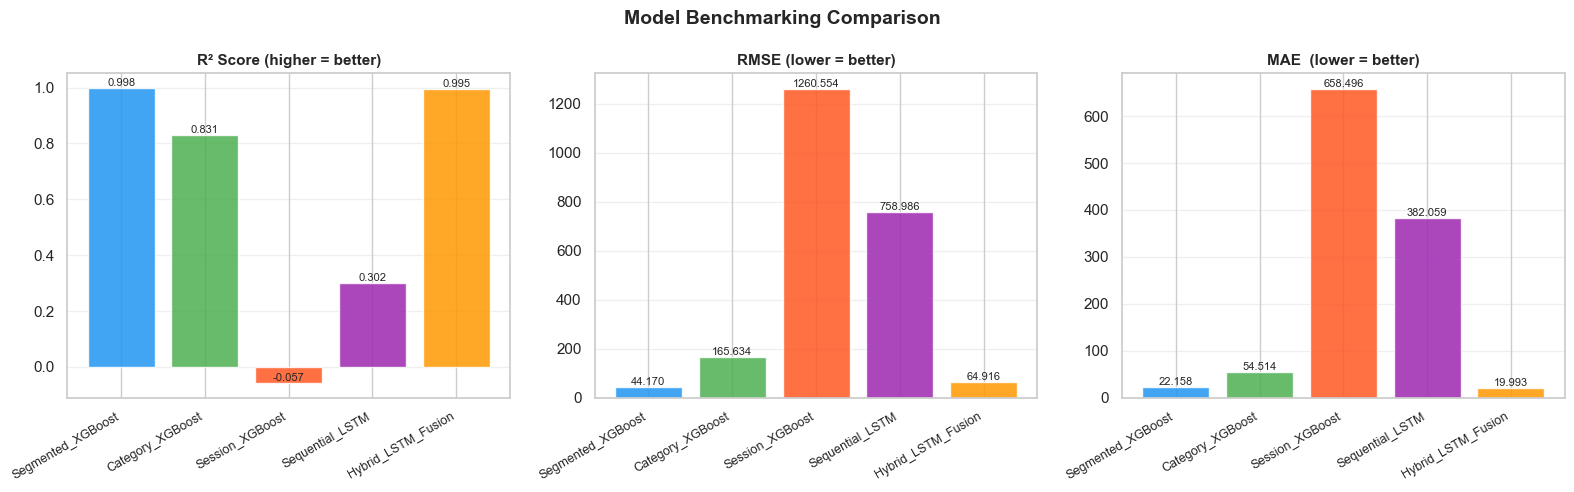

In [ ]:
# 31. ── Safe Benchmarking — handles missing variables gracefully ──────────

# Helper to safely get variable value or return None
def safe_get(var_name):
    try:
        return eval(var_name)
    except NameError:
        print(f"Warning: '{var_name}' not found — setting to None")
        return None

# ── Build benchmark_metrics safely ───────────────────────────────────
benchmark_metrics = {}

# Mean Baseline
if all(v is not None for v in [safe_get('y_pred_dummy'), safe_get('y_test_b')]):
    benchmark_metrics['Mean_Baseline'] = {
        'RMSE': round(float(np.sqrt(mean_squared_error(y_test_b, y_pred_dummy))), 4),
        'MAE' : round(float(mean_absolute_error(y_test_b, y_pred_dummy)), 4),
        'R2'  : round(float(r2_score(y_test_b, y_pred_dummy)), 4)
    }

# Linear Regression
if all(v is not None for v in [safe_get('y_pred_lr'), safe_get('y_test_b')]):
    benchmark_metrics['Linear_Regression'] = {
        'RMSE': round(float(np.sqrt(mean_squared_error(y_test_b, y_pred_lr))), 4),
        'MAE' : round(float(mean_absolute_error(y_test_b, y_pred_lr)), 4),
        'R2'  : round(float(r2_score(y_test_b, y_pred_lr)), 4)
    }

# Segmented XGBoost
if all(v is not None for v in [safe_get('seg_rmse'), 
                                safe_get('seg_mae'), 
                                safe_get('seg_r2')]):
    benchmark_metrics['Segmented_XGBoost'] = {
        'RMSE': seg_rmse,
        'MAE' : seg_mae,
        'R2'  : seg_r2
    }

# Category XGBoost
if all(v is not None for v in [safe_get('cat_rmse'), 
                                safe_get('cat_mae'), 
                                safe_get('cat_r2')]):
    benchmark_metrics['Category_XGBoost'] = {
        'RMSE': cat_rmse,
        'MAE' : cat_mae,
        'R2'  : cat_r2
    }

# Session-Based XGBoost
if all(v is not None for v in [safe_get('sess_rmse'),
                                safe_get('sess_mae'),
                                safe_get('sess_r2')]):
    benchmark_metrics['Session_XGBoost'] = {
        'RMSE': sess_rmse,
        'MAE' : sess_mae,
        'R2'  : sess_r2
    }

# Sequential LSTM
if all(v is not None for v in [safe_get('lstm_seq_rmse'), 
                                safe_get('lstm_seq_mae'), 
                                safe_get('lstm_seq_r2')]):
    benchmark_metrics['Sequential_LSTM'] = {
        'RMSE': lstm_seq_rmse,
        'MAE' : lstm_seq_mae,
        'R2'  : lstm_seq_r2
    }
    
# Hybrid LSTM Feature Fusion
if all(v is not None for v in [safe_get('hybrid_lstm_rmse'),
                                safe_get('hybrid_lstm_mae'),
                                safe_get('hybrid_lstm_r2')]):
    benchmark_metrics['Hybrid_LSTM_Fusion'] = {
        'RMSE': hybrid_lstm_rmse,
        'MAE' : hybrid_lstm_mae,
        'R2'  : hybrid_lstm_r2
    }

# ── Build DataFrame ───────────────────────────────────────────────────
benchmark_df = pd.DataFrame(benchmark_metrics).T
benchmark_df.index.name = 'Model'
benchmark_df = benchmark_df.round(4)

print("\n── Model Benchmarking Results ───────────────")
print(benchmark_df.to_string())

# ── Visual Plot ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Benchmarking Comparison', 
             fontsize=14, fontweight='bold')

colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0', '#FF9800', '#795548', '#607D8B']
models = benchmark_df.index.tolist()
x      = np.arange(len(models))

for ax, (metric, title) in zip(axes, [('R2',   'R² Score (higher = better)'),
                                       ('RMSE', 'RMSE (lower = better)'),
                                       ('MAE',  'MAE  (lower = better)')]):
    if metric not in benchmark_df.columns:
        continue
    bars = ax.bar(x, benchmark_df[metric], color=colors[:len(models)], 
                  alpha=0.85, edgecolor='white')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=30, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


── Hybrid LSTM vs Sequential LSTM ───────────
                        RMSE       MAE      R2
Model                                         
Hybrid_LSTM_Fusion   64.9160   19.9934  0.9949
Sequential_LSTM     758.9855  382.0593  0.3020


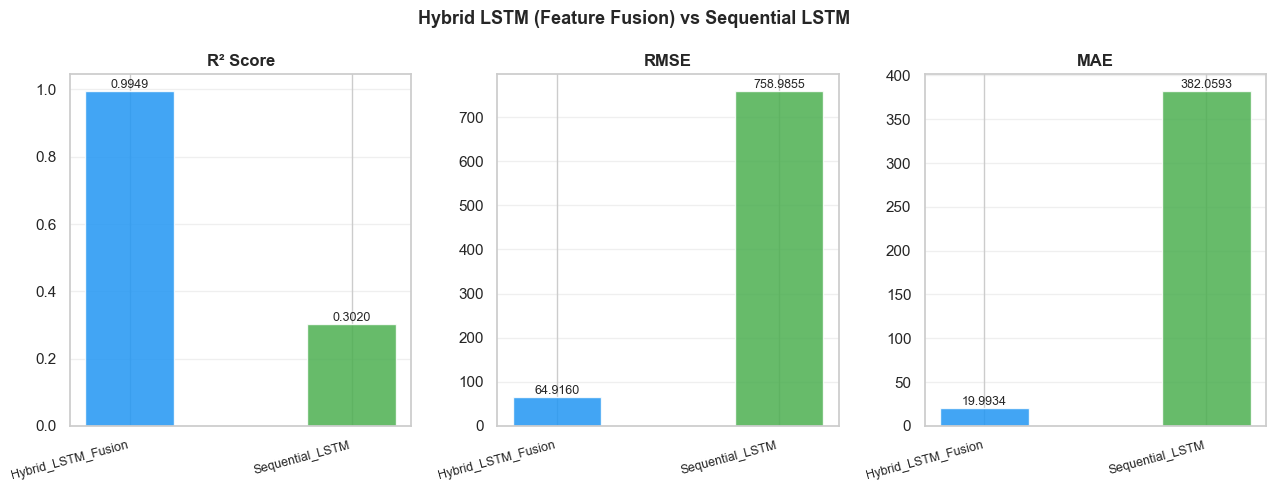

In [44]:
# 32. Subset comparison: Only Hybrid LSTM and Sequential LSTM 

available = [m for m in ['Hybrid_LSTM_Fusion', 'Sequential_LSTM'] 
             if m in benchmark_df.index]

if len(available) == 0:
    print("Neither model found in benchmark_df.")
    print(f"Available models: {benchmark_df.index.tolist()}")

else:
    benchmark_subset_df = benchmark_df.loc[available]
    
    print("\n── Hybrid LSTM vs Sequential LSTM ───────────")
    print(benchmark_subset_df.to_string())

    # ── Visual comparison ─────────────────────────────────────────────
    import matplotlib.pyplot as plt
    import numpy as np

    fig, axes = plt.subplots(1, 3, figsize=(13, 5))
    fig.suptitle('Hybrid LSTM (Feature Fusion) vs Sequential LSTM', 
             fontsize=13, fontweight='bold')

    metrics = [('R2',   'R² Score',  ['#2196F3', '#4CAF50']),
               ('RMSE', 'RMSE',      ['#2196F3', '#4CAF50']),
               ('MAE',  'MAE',       ['#2196F3', '#4CAF50'])]

    x     = np.arange(len(available))
    width = 0.4

    for ax, (col, title, colors) in zip(axes, metrics):
        if col not in benchmark_subset_df.columns:
            continue
        bars = ax.bar(x, benchmark_subset_df[col], 
                      width  = width,
                      color  = colors[:len(available)],
                      alpha  = 0.85,
                      edgecolor = 'white')
        ax.set_title(title, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(available, rotation=15, ha='right', fontsize=9)
        ax.grid(axis='y', alpha=0.3)

        # Value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.4f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

In [ ]:
# 33.Visualising Hybrid LSTM and Sequential LSTM -- don't run

sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics   = ['RMSE', 'MAE', 'R2']

for i, metric in enumerate(metrics):
    values = benchmark_subset_df[metric].values

    sns.barplot(
        ax      = axes[i],
        x       = benchmark_subset_df.index,
        y       = values,
        hue     = benchmark_subset_df.index,
        palette = "coolwarm",
        legend  = False
    )

    axes[i].set_title(f'{metric} Comparison', fontweight='bold')
    axes[i].set_ylabel(metric)
    axes[i].set_xlabel('Model')

    # Fix ylim — handle negative values (e.g. R² = -1.256)
    min_val = min(values.min(), 0)
    max_val = values.max()
    axes[i].set_ylim(min_val * 1.3 if min_val < 0 else 0,
                     max_val * 1.2)

    # Add value labels on each bar
    for bar in axes[i].patches:
        height = bar.get_height()
        axes[i].text(
            bar.get_x() + bar.get_width() / 2.,
            height + (max_val * 0.02),
            f'{height:.4f}',
            ha       = 'center',
            va       = 'bottom',
            fontsize = 9,
            fontweight = 'bold'
        )

    # Add horizontal line at 0 for R² chart
    if metric == 'R2':
        axes[i].axhline(y=0, color='red', linestyle='--', 
                        linewidth=1, alpha=0.7, label='y=0 baseline')
        axes[i].legend(fontsize=8)

plt.suptitle('Hybrid LSTM vs Sequential LSTM: Metric Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
# 34. Data preparation (add this) -- don't run
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_val = X_test
y_val = y_test

# 1. Define the plotting function
def plot_lstm_training(history):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
    plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='--')
    plt.title('LSTM Training vs Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

# 2. Model definition (add this)
lstm_model = tf.keras.Sequential([
    layers.LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    layers.LSTM(32),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')

# 3. Your existing training and plotting code
history = lstm_model.fit(X_train, y_train, 
                         validation_data=(X_val, y_val),
                         epochs=50, 
                         batch_size=32,
                         verbose=1)

plot_lstm_training(history)

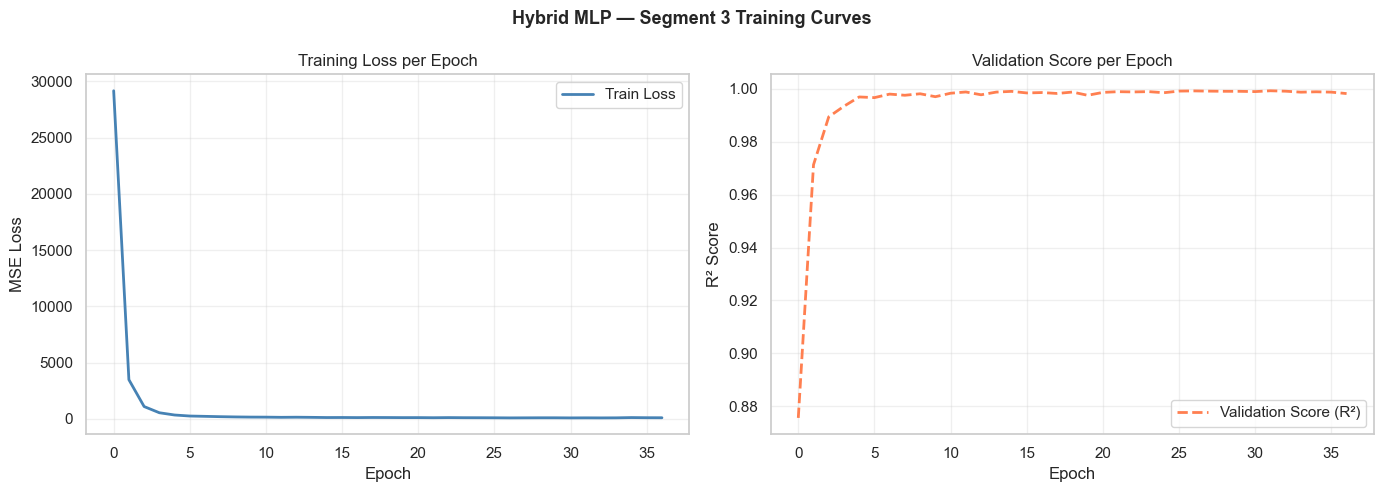


Training Summary:
  Total epochs run  : 37
  Initial loss      : 29160.483536
  Final loss        : 91.383791
  Best loss         : 79.308992


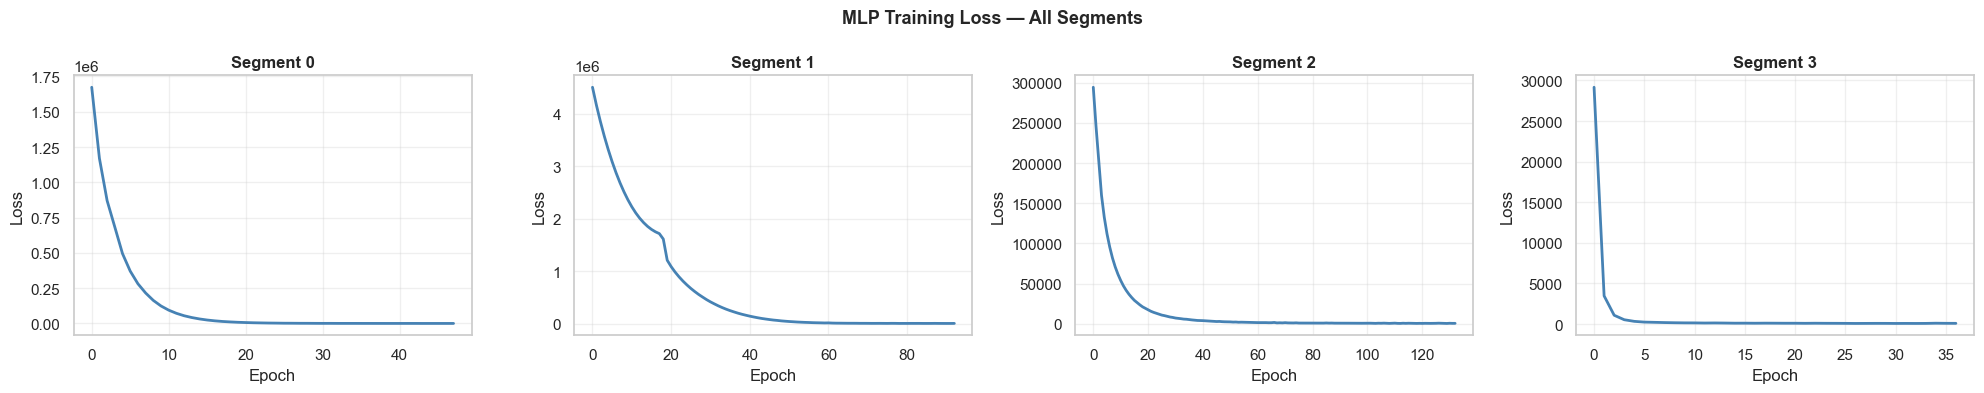

In [45]:
# 35. MLP Loss and Validation plot (replaces LSTM history plot)

def plot_mlp_training(model, model_name='MLP'):
    """
    Plots training loss curve from sklearn MLPRegressor.
    Uses loss_curve_ for train and validation_scores_ for validation.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{model_name} Training Curves', 
                 fontsize=13, fontweight='bold')

    # ── Train Loss Curve ──────────────────────────────────────────────
    if hasattr(model, 'loss_curve_'):
        axes[0].plot(model.loss_curve_, 
                     label='Train Loss', 
                     linewidth=2, 
                     color='steelblue')
        axes[0].set_title('Training Loss per Epoch')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('MSE Loss')
        axes[0].legend()
        axes[0].grid(alpha=0.3)
    else:
        axes[0].text(0.5, 0.5, 'No loss curve available',
                     ha='center', va='center',
                     transform=axes[0].transAxes)

    # ── Validation Score Curve ────────────────────────────────────────
    if hasattr(model, 'validation_scores_') and model.validation_scores_:
        axes[1].plot(model.validation_scores_,
                     label='Validation Score (R²)',
                     linewidth=2,
                     linestyle='--',
                     color='coral')
        axes[1].set_title('Validation Score per Epoch')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('R² Score')
        axes[1].legend()
        axes[1].grid(alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, 'No validation curve available',
                     ha='center', va='center',
                     transform=axes[1].transAxes)

    plt.tight_layout()
    plt.show()

    # Print summary
    if hasattr(model, 'loss_curve_'):
        print(f"\nTraining Summary:")
        print(f"  Total epochs run  : {len(model.loss_curve_)}")
        print(f"  Initial loss      : {model.loss_curve_[0]:.6f}")
        print(f"  Final loss        : {model.loss_curve_[-1]:.6f}")
        print(f"  Best loss         : {min(model.loss_curve_):.6f}")


# ── Option 1: Plot last trained segment model ─────────────────────────
# Get the last segment's MLP model
last_seg = sorted(segment_models.keys())[-1]
last_mlp = segment_models[last_seg]['MLP']
plot_mlp_training(last_mlp, model_name=f'Hybrid MLP — Segment {last_seg}')


# ── Option 2: Plot all segments in one figure ─────────────────────────
fig, axes = plt.subplots(1, len(segment_models), 
                          figsize=(5 * len(segment_models), 4))

# Handle case where only 1 segment exists
if len(segment_models) == 1:
    axes = [axes]

for ax, (seg, models) in zip(axes, sorted(segment_models.items())):
    mlp = models['MLP']
    if hasattr(mlp, 'loss_curve_'):
        ax.plot(mlp.loss_curve_, linewidth=2, color='steelblue')
        ax.set_title(f'Segment {seg}', fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.grid(alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No curve', ha='center', 
                va='center', transform=ax.transAxes)

fig.suptitle('MLP Training Loss — All Segments', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


── Final Benchmark Comparison Across All Models ─────────────
                         RMSE       MAE      R2
Segmented_XGBoost     44.1701   22.1584  0.9983
Category_XGBoost     165.6340   54.5137  0.8311
Session_XGBoost     1260.5539  658.4963 -0.0570
Sequential_LSTM      758.9855  382.0593  0.3020
Hybrid_LSTM_Fusion    64.9160   19.9934  0.9949


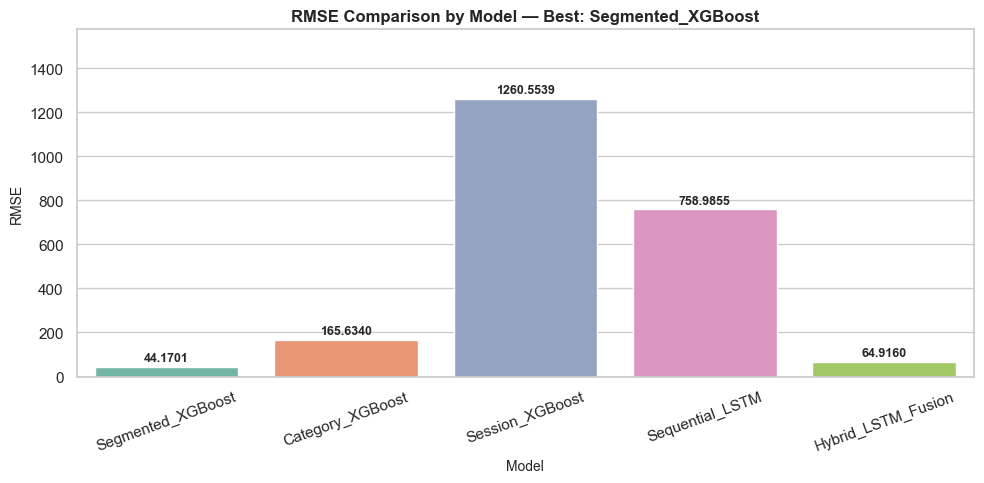

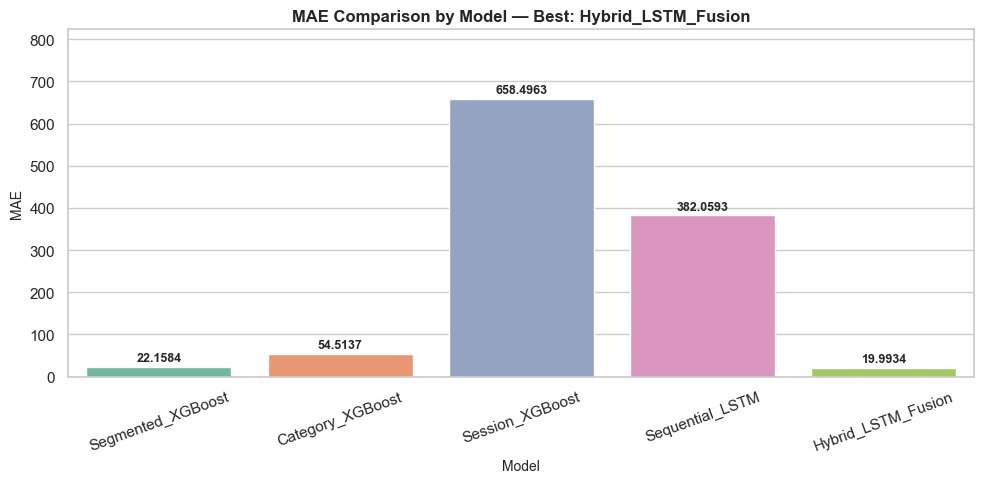

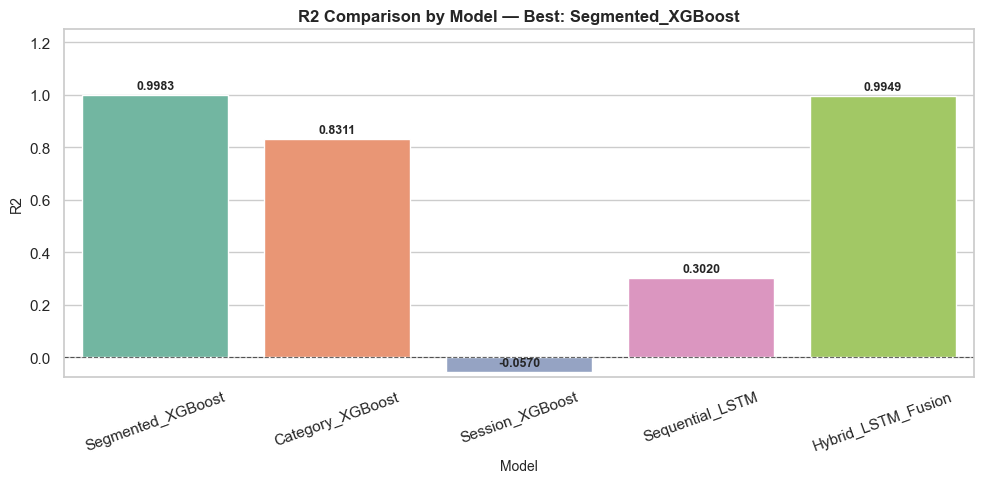

In [46]:
# 36.Final benchmarking across all models

benchmark_df = pd.DataFrame(benchmark_metrics).T
print("\n── Final Benchmark Comparison Across All Models ─────────────")
print(benchmark_df.round(4).to_string())

# ── Final Benchmark Visualisations ───────────────────────────────────
benchmark_plot_df = (pd.DataFrame(benchmark_metrics).T
                       .reset_index()
                       .rename(columns={"index": "Model"}))

# Melt for seaborn
comparison_df = benchmark_plot_df.melt(
    id_vars  = "Model",
    var_name = "Metric",
    value_name = "Score"
)
comparison_df['Score'] = comparison_df['Score'].astype(float)

sns.set(style="whitegrid")

for metric in ['RMSE', 'MAE', 'R2']:

    if metric not in comparison_df['Metric'].values:
        continue

    metric_data = comparison_df[comparison_df['Metric'] == metric].copy()

    plt.figure(figsize=(10, 5))

    ax = sns.barplot(
        data    = metric_data,
        x       = "Model",
        y       = "Score",
        hue     = "Model",
        palette = "Set2",
        legend  = False
    )

    # Dynamic y limits — handles negative R²
    min_val = metric_data['Score'].min()
    max_val = metric_data['Score'].max()
    ax.set_ylim(min_val * 1.3 if min_val < 0 else 0,
                max_val * 1.25)

    # Zero baseline
    ax.axhline(0, color='black', linestyle='--',
               linewidth=0.8, alpha=0.6)

    # Value labels on bars
    for bar in ax.patches:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.,
            height + (max_val * 0.01),
            f'{height:.4f}',
            ha         = 'center',
            va         = 'bottom',
            fontsize   = 9,
            fontweight = 'bold'
        )

    # Best model annotation
    if metric == 'R2':
        best_model = metric_data.loc[metric_data['Score'].idxmax(), 'Model']
        note = f"Best: {best_model}"
    else:
        best_model = metric_data.loc[metric_data['Score'].idxmin(), 'Model']
        note = f"Best: {best_model}"

    ax.set_title(f"{metric} Comparison by Model — {note}",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel("Model", fontsize=10)
    ax.set_ylabel(metric,  fontsize=10)
    ax.tick_params(axis='x', rotation=20)

    plt.tight_layout()
    plt.show()


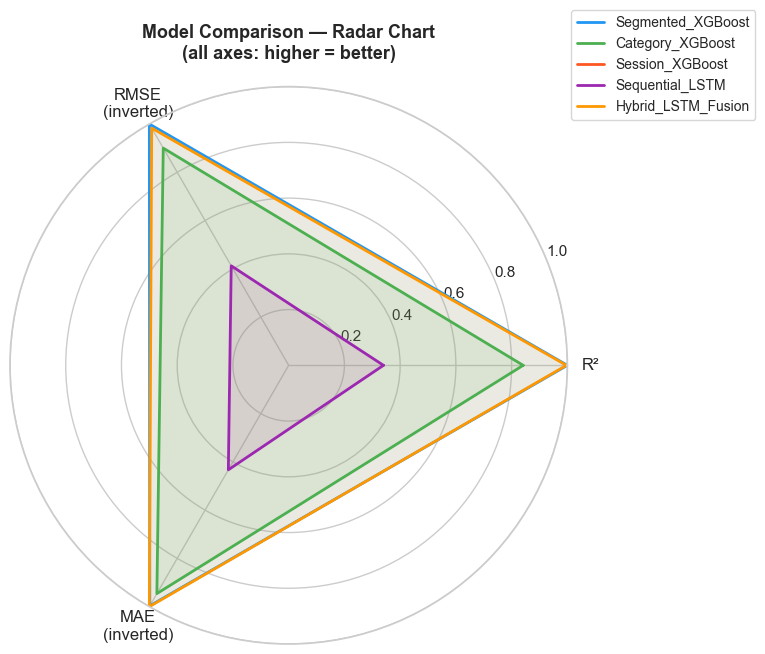

In [47]:
# 37.Final benchmarking across all models

def plot_radar(benchmark_df):
    # Normalise all metrics 0-1 for radar
    # For RMSE and MAE: invert so higher = better on all axes
    df = benchmark_df.copy().astype(float)
    
    df_norm = df.copy()
    df_norm['R2']   = (df['R2']   - df['R2'].min())   / (df['R2'].max()   - df['R2'].min() + 1e-9)
    df_norm['RMSE'] = 1 - (df['RMSE'] - df['RMSE'].min()) / (df['RMSE'].max() - df['RMSE'].min() + 1e-9)
    df_norm['MAE']  = 1 - (df['MAE']  - df['MAE'].min())  / (df['MAE'].max()  - df['MAE'].min()  + 1e-9)

    categories = ['R²', 'RMSE\n(inverted)', 'MAE\n(inverted)']
    N          = len(categories)
    angles     = [n / float(N) * 2 * np.pi for n in range(N)]
    angles    += angles[:1]  # close the polygon

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    colors  = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0', '#FF9800']

    for i, (model, row) in enumerate(df_norm.iterrows()):
        values  = row[['R2', 'RMSE', 'MAE']].tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2,
                color=colors[i % len(colors)], label=model)
        ax.fill(angles, values, alpha=0.1,
                color=colors[i % len(colors)])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=12)
    ax.set_ylim(0, 1)
    ax.set_title('Model Comparison — Radar Chart\n(all axes: higher = better)',
                 fontsize=13, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
    plt.tight_layout()
    plt.show()

plot_radar(benchmark_df)

In [48]:
# Check if benchmark_metrics exists
if 'benchmark_metrics' not in locals():
    print("benchmark_metrics not found. Run some model training first.")
    print("Available variables:", [name for name in locals() if 'metric' in name.lower()])
else:
    print(f"benchmark_metrics contains {len(benchmark_metrics)} models")
    for model, metrics in benchmark_metrics.items():
        print(f"  {model}: {metrics}")

# Debug information
print("benchmark_df shape:", benchmark_df.shape)
print("benchmark_df columns:", benchmark_df.columns.tolist())
print("benchmark_df index:", benchmark_df.index.tolist())
print(benchmark_df.head())

benchmark_metrics contains 5 models
  Segmented_XGBoost: {'RMSE': np.float64(44.170075), 'MAE': np.float64(22.158425), 'R2': np.float64(0.9983000000000001)}
  Category_XGBoost: {'RMSE': np.float64(165.63396233145076), 'MAE': np.float64(54.5137307875436), 'R2': np.float64(0.8311006873034711)}
  Session_XGBoost: {'RMSE': 1260.5539151982769, 'MAE': 658.4962841667765, 'R2': -0.05695942915587726}
  Sequential_LSTM: {'RMSE': 758.9855071080079, 'MAE': 382.059326171875, 'R2': 0.3019595742225647}
  Hybrid_LSTM_Fusion: {'RMSE': 64.91599138502006, 'MAE': 19.99343490600586, 'R2': 0.9948935508728027}
benchmark_df shape: (5, 3)
benchmark_df columns: ['RMSE', 'MAE', 'R2']
benchmark_df index: ['Segmented_XGBoost', 'Category_XGBoost', 'Session_XGBoost', 'Sequential_LSTM', 'Hybrid_LSTM_Fusion']
                           RMSE         MAE        R2
Segmented_XGBoost     44.170075   22.158425  0.998300
Category_XGBoost     165.633962   54.513731  0.831101
Session_XGBoost     1260.553915  658.496284 -0.056